In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np


cwd = Path.cwd()
print(cwd)
root=cwd.parents[1]
# os.chdir(root/"Seb_branch"/"institutional-roi-analysis"/"notebooks")
pd.set_option("display.max_columns",None)
display(root)

c:\Users\sebas\PycharmProjects\Git\Seb_branch\institutional-roi-analysis\notebooks\national_models


WindowsPath('c:/Users/sebas/PycharmProjects/Git/Seb_branch/institutional-roi-analysis')

### Feature Selection for Explanatory Model

Variables used in the initial prediction model (e.g., credential level, distance, and other structural constraints) were excluded from the explanatory model.

This is because the residuals already represent performance after controlling for these factors. Including them again would introduce circular reasoning and reduce the interpretability of the results.

Instead, the explanatory model focuses on institutional characteristics and program composition variables that were not used in the prediction stage, allowing us to better understand what drives over- and underperformance.

In [2]:
driver_df=pd.read_csv(root/'data'/'raw'/'scorecard'/'raw_national_inst_driver.csv')

In [3]:
driver_df["has_endowment"] = (
    driver_df["endowment_begin"].notna() &
    driver_df["endowment_end"].notna()
).astype(int)

In [4]:
driver_df["has_endowment"].describe()

count    6322.000000
mean        0.422018
std         0.493920
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: has_endowment, dtype: float64

In [5]:
driver_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6322 entries, 0 to 6321
Data columns (total 49 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   program_percentage_agriculture                           5582 non-null   float64
 1   program_percentage_resources                             5582 non-null   float64
 2   program_percentage_architecture                          5582 non-null   float64
 3   program_percentage_ethnic_cultural_gender                5582 non-null   float64
 4   program_percentage_communication                         5582 non-null   float64
 5   program_percentage_communications_technology             5582 non-null   float64
 6   program_percentage_computer                              5582 non-null   float64
 7   program_percentage_personal_culinary                     5582 non-null   float64
 8   program_percentage_education

In [6]:
ridge_residual_df = pd.read_csv(root/"data"/"raw"/"scorecard"/"raw_national_residual_programs.csv")
xgb_residual_df = pd.read_csv(root/"data"/"raw"/"scorecard"/"raw_xgb_national_residual_programs.csv")

In [7]:
# Do the year errors generally agree in direction?
ridge_residual_df['sign_agreement'] = (
    np.sign(ridge_residual_df['1_year_error']) == 
    np.sign(ridge_residual_df['4_year_error'])
) & (
    np.sign(ridge_residual_df['4_year_error']) == 
    np.sign(ridge_residual_df['5_year_error'])
)

print(ridge_residual_df['sign_agreement'].value_counts(normalize=True))

# Also check correlation between year errors
print(ridge_residual_df[['1_year_error','4_year_error','5_year_error']].corr())

sign_agreement
True     0.61211
False    0.38789
Name: proportion, dtype: float64
              1_year_error  4_year_error  5_year_error
1_year_error      1.000000      0.798756      0.714188
4_year_error      0.798756      1.000000      0.816227
5_year_error      0.714188      0.816227      1.000000


In [8]:
# Do the year errors generally agree in direction?
xgb_residual_df['sign_agreement'] = (
    np.sign(xgb_residual_df['1_year_error']) == 
    np.sign(xgb_residual_df['4_year_error'])
) & (
    np.sign(xgb_residual_df['4_year_error']) == 
    np.sign(xgb_residual_df['5_year_error'])
)

print(xgb_residual_df['sign_agreement'].value_counts(normalize=True))

# Also check correlation between year errors
print(xgb_residual_df[['1_year_error','4_year_error','5_year_error']].corr())

sign_agreement
True    1.0
Name: proportion, dtype: float64
              1_year_error  4_year_error  5_year_error
1_year_error      1.000000      0.851905      0.799568
4_year_error      0.851905      1.000000      0.841716
5_year_error      0.799568      0.841716      1.000000


In [9]:
ridge_residual_df['total_pred'] = ridge_residual_df[
    ["1_year_pred", "4_year_pred", "5_year_pred"]
].sum(axis=1)

ridge_residual_df["total_count"] = (
    ridge_residual_df["1_yr_working_count"] +
    ridge_residual_df["4_yr_working_count"] +
    ridge_residual_df["5_yr_working_count"]
)

k = np.percentile(np.log1p(ridge_residual_df["total_count"]), 75)

ridge_residual_df["weight"] = (
    np.log1p(ridge_residual_df["total_count"]) /
    np.log1p(ridge_residual_df["total_count"] + k)
)

ridge_residual_df["combined_pct_error"] = ridge_residual_df[
    ["1_year_error", "4_year_error", "5_year_error"]
].median(axis=1) / ridge_residual_df['total_pred'] * 3

# consistent_mask = ridge_residual_df['sign_agreement'] == True
# ridge_residual_df = ridge_residual_df[consistent_mask]
# print(f"Consistent schools: {consistent_mask.sum()} of {len(ridge_residual_df)}")

ridge_residual_df.head()

,code,credential_level,unit_id,distance,school_type,5_yr_working_count,school_state,location_lat,location_lon,locale,carnegie_size_setting,admission_rate_overall,median_family_income,students_with_pell_grant,open_admissions_policy,age_entry,title_iv_eligibility_type,sat_scores_average_overall,act_scores_midpoint_cumulative,grad_students,selectivity_bucket,5_year_earning_log,5_year_pred_log,title,school_name,5_year_earning,5_year_pred,5_year_error,4_year_earning,4_year_earning_log,4_year_pred,4_year_pred_log,4_year_error,4_yr_working_count,1_year_earning,1_year_earning_log,1_year_pred,1_year_pred_log,1_year_error,1_yr_working_count,school_count,confidence,1_year_pct_error,1_year_score,4_year_pct_error,4_year_score,5_year_pct_error,5_year_score,rank_1,rank_4,rank_5,move_1_to_4,move_4_to_5,move_1_to_5,rank_std,rank_std_pct,mean_rank_std_pct,median_score,sign_agreement,total_pred,total_count,weight,combined_pct_error
0,100,3,110422,1,Public,21.0,CA,35.299513,NaN,23,16.0,0.3132,74513.0,0.455561,2.0,20.0,1,NaN,NaN,1036.0,mid,11.132397,11.027100,"Agriculture, General.",California Polytechnic State University-San Lu...,68350.0,61518.918041,6831.081959,84412.0,11.343465,61849.328337,11.032457,22562.671663,36,64786.0,11.078845,44661.282885,10.706862,20124.717115,18.0,28,high,0.450608,0.418702,0.364801,0.352710,0.111040,0.104505,2.0,2.0,10.0,0.0,8.0,8.0,4.618802,0.171067,0.16765,0.352710,True,168029.529263,75.0,0.983097,0.359307
1,100,3,130934,1,Public,24.0,DE,39.187173,NaN,13,14.0,0.4658,39554.0,0.685488,2.0,20.0,1,940.0,NaN,746.0,mid,10.768022,10.889413,"Agriculture, General.",Delaware State University,47478.0,53605.820876,-6127.820876,52676.0,10.871915,54423.909124,10.904559,-1747.909124,24,38873.0,10.568055,39038.464664,10.572303,-165.464664,22.0,28,high,-0.004239,-0.003998,-0.032117,-0.030432,-0.114313,-0.108515,16.0,15.0,18.0,-1.0,3.0,2.0,1.527525,0.056575,0.16765,-0.030432,True,147068.194664,70.0,0.981691,-0.035655
2,100,3,145813,1,Public,132.0,IL,40.509403,NaN,22,16.0,0.8815,67099.0,0.481270,2.0,20.0,1,1113.0,24.0,2439.0,open,11.067279,10.967096,"Agriculture, General.",Illinois State University,64041.0,57936.128323,6104.871677,63600.0,11.060369,59188.291176,10.988479,4411.708824,214,47295.0,10.764160,44425.661994,10.701573,2869.338006,205.0,28,high,0.064587,0.064311,0.074537,0.074227,0.105372,0.104631,11.0,8.0,9.0,-3.0,1.0,-2.0,1.527525,0.056575,0.16765,0.074227,True,161550.081493,551.0,0.998326,0.081926
3,100,3,149222,1,Public,23.0,IL,37.714193,NaN,32,14.0,0.8688,37454.0,0.655376,2.0,22.0,1,1055.0,24.0,3237.0,open,11.051382,10.804913,"Agriculture, General.",Southern Illinois University-Carbondale,63031.0,49262.255760,13768.744240,57596.0,10.961208,50034.114619,10.820460,7561.885381,47,39700.0,10.589106,38819.886275,10.566688,880.113725,22.0,28,high,0.022672,0.021384,0.151135,0.147450,0.279499,0.264632,13.0,4.0,2.0,-9.0,-2.0,-11.0,5.859465,0.217017,0.16765,0.147450,True,138116.256654,92.0,0.986666,0.164250
4,100,3,149772,1,Public,145.0,IL,40.468086,NaN,33,13.0,0.7118,36222.0,0.684009,2.0,21.0,1,NaN,NaN,1807.0,open,10.971709,10.873760,"Agriculture, General.",Western Illinois University,58204.0,52773.247380,5430.752620,58333.0,10.973923,52459.403970,10.867795,5873.596030,160,48509.0,10.789505,38882.312529,10.568295,9626.687471,149.0,28,high,0.247585,0.246045,0.111965,0.111311,0.102907,0.102258,4.0,5.0,11.0,1.0,6.0,7.0,3.785939,0.140220,0.16765,0.111311,True,144114.963878,454.0,0.997908,0.122269


In [10]:
xgb_residual_df['total_pred'] = xgb_residual_df[
    ["1_year_pred", "4_year_pred", "5_year_pred"]
].sum(axis=1)

xgb_residual_df["total_count"] = (
    xgb_residual_df["1_yr_working_count"] +
    xgb_residual_df["4_yr_working_count"] +
    xgb_residual_df["5_yr_working_count"]
)

k = np.percentile(np.log1p(xgb_residual_df["total_count"]), 75)

xgb_residual_df["weight"] = (
    np.log1p(xgb_residual_df["total_count"]) /
    np.log1p(xgb_residual_df["total_count"] + k)
)

xgb_residual_df["combined_pct_error"] = xgb_residual_df[
    ["1_year_error", "4_year_error", "5_year_error"]
].median(axis=1) / xgb_residual_df['total_pred'] * 3

# consistent_mask = xgb_residual_df['sign_agreement'] == True
# xgb_residual_df = xgb_residual_df[consistent_mask]
# print(f"Consistent schools: {consistent_mask.sum()} of {len(xgb_residual_df)}")

xgb_residual_df.head()

,code,credential_level,unit_id,distance,school_type,5_yr_working_count,school_state,location_lat,location_lon,locale,carnegie_size_setting,admission_rate_overall,median_family_income,students_with_pell_grant,open_admissions_policy,age_entry,title_iv_eligibility_type,sat_scores_average_overall,act_scores_midpoint_cumulative,grad_students,selectivity_bucket,5_year_earning_log,5_year_pred_log,title,school_name,5_year_earning,5_year_pred,5_year_error,4_year_earning,4_year_earning_log,4_year_pred,4_year_pred_log,4_year_error,4_yr_working_count,1_year_earning,1_year_earning_log,1_year_pred,1_year_pred_log,1_year_error,1_yr_working_count,school_count,confidence,1_year_pct_error,1_year_score,4_year_pct_error,4_year_score,5_year_pct_error,5_year_score,rank_1,rank_4,rank_5,move_1_to_4,move_4_to_5,move_1_to_5,rank_std,rank_std_pct,mean_rank_std_pct,median_score,sign_agreement,total_pred,total_count,weight,combined_pct_error
0,100,3,130934,1,Public,24.0,DE,39.187173,NaN,13,14.0,0.4658,39554.0,0.685488,2.0,20.0,1,940.0,NaN,746.0,mid,10.768022,10.994006,"Agriculture, General.",Delaware State University,47478.0,59516.336,-12038.335937,52676.0,10.871915,59364.930,10.991459,-6688.929687,24,38873.0,10.568055,40220.414,10.602130,-1347.414063,22.0,28,high,-0.033501,-0.031598,-0.112675,-0.106766,-0.202269,-0.192011,18.0,18.0,24.0,0.0,6.0,6.0,3.464102,0.128300,0.186109,-0.106766,True,159101.680,70.0,0.981356,-0.126126
1,100,3,145813,1,Public,132.0,IL,40.509403,NaN,22,16.0,0.8815,67099.0,0.481270,2.0,20.0,1,1113.0,24.0,2439.0,open,11.067279,10.992542,"Agriculture, General.",Illinois State University,64041.0,59429.277,4611.722656,63600.0,11.060369,61214.746,11.022143,2385.253906,214,47295.0,10.764160,42545.203,10.658322,4749.796875,205.0,28,high,0.111641,0.111163,0.038965,0.038803,0.077600,0.077054,8.0,6.0,8.0,-2.0,2.0,0.0,1.154701,0.042767,0.186109,0.077054,True,163189.226,551.0,0.998294,0.084780
2,100,3,149222,1,Public,23.0,IL,37.714193,NaN,32,14.0,0.8688,37454.0,0.655376,2.0,22.0,1,1055.0,24.0,3237.0,open,11.051382,10.850296,"Agriculture, General.",Southern Illinois University-Carbondale,63031.0,51549.410,11481.589844,57596.0,10.961208,53784.330,10.892737,3811.671875,47,39700.0,10.589106,38761.050,10.565171,938.949219,22.0,28,high,0.024224,0.022848,0.070870,0.069142,0.222730,0.210883,13.0,5.0,1.0,-8.0,-4.0,-12.0,6.110101,0.226300,0.186109,0.069142,True,144094.790,92.0,0.986418,0.079358
3,100,3,149772,1,Public,145.0,IL,40.468086,NaN,33,13.0,0.7118,36222.0,0.684009,2.0,21.0,1,NaN,NaN,1807.0,open,10.971709,10.893735,"Agriculture, General.",Western Illinois University,58204.0,53838.008,4365.992187,58333.0,10.973923,53683.992,10.890870,4649.007813,160,48509.0,10.789505,39219.414,10.576927,9289.585938,149.0,28,high,0.236862,0.235389,0.086600,0.086094,0.081095,0.080584,4.0,4.0,7.0,0.0,3.0,3.0,1.732051,0.064150,0.186109,0.086094,True,146741.414,454.0,0.997868,0.095045
4,100,3,157386,0,Public,60.0,KY,38.186768,NaN,33,13.0,0.7721,35407.0,0.689286,2.0,22.0,1,NaN,NaN,533.0,open,10.692785,10.898738,"Agriculture, General.",Morehead State University,44037.0,54108.030,-10071.031250,45255.0,10.720068,54223.120,10.900863,-8968.121094,91,34670.0,10.453630,38868.105,10.567929,-4198.105469,75.0,28,high,-0.108009,-0.106509,-0.165393,-0.163526,-0.186128,-0.182833,25.0,22.0,23.0,-3.0,1.0,-2.0,1.527525,0.056575,0.186109,-0.163526,True,147199.255,226.0,0.995223,-0.182775


In [11]:
# rerun stage 2 but use Ridge stage 1 residuals instead
# you already have ridge_residuals from when you ran Ridge in stage 1

# quick check — what's the variance of each residual type?
print("XGBoost residual std:", xgb_residual_df["combined_pct_error"].std())
print("Ridge residual std:  ", ridge_residual_df["combined_pct_error"].std())

# XGBoost residual should be much smaller — it explained more
# Ridge residual should be larger — more leftover for stage 2

XGBoost residual std: 0.179119836461294
Ridge residual std:   0.1871690522887098


In [12]:
join_cols=["unit_id"]
for col in join_cols:
    driver_df[col] = driver_df[col].astype(str).str.strip()
    ridge_residual_df[col] = ridge_residual_df[col].astype(str).str.strip()


### Target Variable Selection

While a composite scoring metric was developed to rank program-level variability, it was not used as the target for the explanatory model.

Instead, the model uses the average  raw percentage error of years 1, 4, and 5 as the target:

  * pct_error = error / predicted

This decision ensures that the model learns directly from observed over- and underperformance, rather than from a derived metric that incorporates additional adjustments (e.g., sample size penalties and variability scaling).

The composite score remains useful for identifying high-variability groups, but the explanatory model focuses on the underlying performance signal.

In [13]:
# residual_df["combined_pct_error"]=(
#     residual_df[['1_year_error','4_year_error','5_year_error']].sum(axis=1)
#     /
#     residual_df[['1_year_pred','4_year_pred','5_year_pred']].sum(axis=1)
# )

In [14]:
# compute pct error at row level in dollar space
ridge_residual_df["dollar_error_median"] = ridge_residual_df[
    ["1_year_error", "4_year_error", "5_year_error"]
].median(axis=1)

ridge_residual_df["dollar_pred_median"] = ridge_residual_df[
    ["1_year_pred", "4_year_pred", "5_year_pred"]
].median(axis=1)

ridge_residual_df["row_pct_error"] = (
   ridge_residual_df["dollar_error_median"] / ridge_residual_df["dollar_pred_median"]
)

In [15]:
school_df = ridge_residual_df.groupby("unit_id", as_index=False).agg(
    combined_pct_error=("row_pct_error", "median"),
    avg_rank_stability=("mean_rank_std_pct", "mean"),
    school_name=("school_name", "first"),
    total_count_1=("1_yr_working_count", "sum"),
    total_count_4=("4_yr_working_count", "sum"),
    total_count_5=("5_yr_working_count", "sum"),
)

school_df["total_count"] = (
    school_df["total_count_1"] +
    school_df["total_count_4"] +
    school_df["total_count_5"]
)

k = np.percentile(np.log1p(school_df["total_count"]), 75)
school_df["weight"] = (
    np.log1p(school_df["total_count"]) /
    np.log1p(school_df["total_count"] + k)
)

In [16]:
targ="combined_pct_error"
merge_df=driver_df.merge(school_df[[targ,'unit_id','weight']], on=["unit_id"],how="inner")
merge_df.head()

,program_percentage_agriculture,program_percentage_resources,program_percentage_architecture,program_percentage_ethnic_cultural_gender,program_percentage_communication,program_percentage_communications_technology,program_percentage_computer,program_percentage_personal_culinary,program_percentage_education,program_percentage_engineering,program_percentage_engineering_technology,program_percentage_language,program_percentage_family_consumer_science,program_percentage_legal,program_percentage_english,program_percentage_humanities,program_percentage_library,program_percentage_biological,program_percentage_mathematics,program_percentage_military,program_percentage_multidiscipline,program_percentage_parks_recreation_fitness,program_percentage_philosophy_religious,program_percentage_theology_religious_vocation,program_percentage_physical_science,program_percentage_science_technology,program_percentage_psychology,program_percentage_security_law_enforcement,program_percentage_public_administration_social_service,program_percentage_social_science,program_percentage_construction,program_percentage_mechanic_repair_technology,program_percentage_precision_production,program_percentage_transportation,program_percentage_visual_performing,program_percentage_health,program_percentage_business_marketing,program_percentage_history,instructional_expenditure_per_fte,faculty_salary,ft_faculty_rate,program_reporter_programs_offered,student_faculty_ratio,endowment_begin,endowment_end,dolflag,school_name,unit_id,has_endowment,combined_pct_error,weight
0,0.0407,0.0000,0.0136,0.0000,0.0000,0.0542,0.0424,0.0,0.0424,0.1085,0.0203,0.0000,0.0186,0.0,0.0119,0.0661,0.0,0.1424,0.0051,0.0,0.0000,0.0373,0.0000,0.0,0.0237,0.0000,0.0559,0.0644,0.0441,0.0220,0.0,0.0,0.0,0.0,0.0186,0.0000,0.1678,0.0000,7254.0,8699.0,0.6439,NaN,19.0,NaN,NaN,0.0,Alabama A & M University,100654,0,-0.068437,0.999317
1,0.0000,0.0000,0.0000,0.0007,0.0189,0.0000,0.0352,0.0,0.0541,0.0541,0.0000,0.0078,0.0000,0.0,0.0150,0.0303,0.0,0.1489,0.0055,0.0,0.0036,0.0000,0.0036,0.0,0.0176,0.0007,0.0762,0.0358,0.0163,0.0267,0.0,0.0,0.0,0.0,0.0274,0.2111,0.1997,0.0108,17855.0,12612.0,0.7704,NaN,18.0,7.393729e+08,8.589892e+08,0.0,University of Alabama at Birmingham,100663,1,-0.022081,0.999934
2,0.0000,0.0000,0.0000,0.0000,0.0102,0.0000,0.0752,0.0,0.0223,0.3155,0.0122,0.0034,0.0020,0.0,0.0223,0.0000,0.0,0.0616,0.0156,0.0,0.0156,0.0271,0.0007,0.0,0.0427,0.0000,0.0251,0.0000,0.0000,0.0156,0.0,0.0,0.0,0.0,0.0413,0.1043,0.1774,0.0102,9877.0,10639.0,0.6590,NaN,17.0,9.962702e+07,1.137376e+08,1.0,University of Alabama in Huntsville,100706,1,0.041734,0.999451
3,0.0000,0.0000,0.0000,0.0000,0.0511,0.0000,0.0404,0.0,0.0745,0.0128,0.0000,0.0000,0.0000,0.0,0.0085,0.0000,0.0,0.1085,0.0064,0.0,0.0979,0.0128,0.0000,0.0,0.0213,0.0000,0.0638,0.1234,0.0383,0.0298,0.0,0.0,0.0,0.0,0.1043,0.0872,0.1191,0.0000,10723.0,8153.0,0.6477,NaN,15.0,1.186163e+08,1.351989e+08,0.0,Alabama State University,100724,1,-0.029958,0.999299
4,0.0000,0.0068,0.0000,0.0014,0.0950,0.0000,0.0163,0.0,0.0250,0.1002,0.0000,0.0033,0.0628,0.0,0.0098,0.0002,0.0,0.0375,0.0080,0.0,0.0138,0.0392,0.0021,0.0,0.0098,0.0000,0.0517,0.0000,0.0100,0.0900,0.0,0.0,0.0,0.0,0.0241,0.0920,0.2911,0.0100,9728.0,11419.0,0.7904,NaN,19.0,1.369440e+09,1.565892e+09,1.0,The University of Alabama,100751,1,0.002167,0.999954


In [17]:
model_df=merge_df.copy()
print("scorecard driver schools:", driver_df['unit_id'].nunique())
print("school_df school:", school_df['unit_id'].nunique())
print("model_df schools:", model_df['unit_id'].nunique())

print("model_df columns:")
print(sorted(model_df.columns.tolist()))

scorecard driver schools: 6322
school_df school: 4327
model_df schools: 4327
model_df columns:
['combined_pct_error', 'dolflag', 'endowment_begin', 'endowment_end', 'faculty_salary', 'ft_faculty_rate', 'has_endowment', 'instructional_expenditure_per_fte', 'program_percentage_agriculture', 'program_percentage_architecture', 'program_percentage_biological', 'program_percentage_business_marketing', 'program_percentage_communication', 'program_percentage_communications_technology', 'program_percentage_computer', 'program_percentage_construction', 'program_percentage_education', 'program_percentage_engineering', 'program_percentage_engineering_technology', 'program_percentage_english', 'program_percentage_ethnic_cultural_gender', 'program_percentage_family_consumer_science', 'program_percentage_health', 'program_percentage_history', 'program_percentage_humanities', 'program_percentage_language', 'program_percentage_legal', 'program_percentage_library', 'program_percentage_mathematics', 'pro

In [18]:
model_df=model_df.drop(columns=[
    # "program_reporter_programs_offered",
    # 'code',
    # 'unit_id',
    # 'school_name'
    ]
)

In [19]:
program_cols = [c for c in model_df.columns if c.startswith("program_percentage_")]

for c in program_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce").fillna(0)

# STEM
model_df["pct_stem"] = model_df[
    [
        "program_percentage_computer",
        "program_percentage_engineering",
        "program_percentage_engineering_technology",
        "program_percentage_mathematics",
        "program_percentage_physical_science",
        "program_percentage_biological",
        "program_percentage_science_technology"
    ]
].sum(axis=1)

# Business / Econ
model_df["pct_business"] = model_df[
    ["program_percentage_business_marketing"]
].sum(axis=1)

# Health
model_df["pct_health"] = model_df[
    ["program_percentage_health"]
].sum(axis=1)

# Social Sciences
model_df["pct_social_science"] = model_df[
    [
        "program_percentage_psychology",
        "program_percentage_social_science",
        "program_percentage_history",
        "program_percentage_public_administration_social_service"
    ]
].sum(axis=1)

# Humanities
model_df["pct_humanities"] = model_df[
    [
        "program_percentage_english",
        "program_percentage_language",
        "program_percentage_humanities",
        "program_percentage_philosophy_religious",
        "program_percentage_theology_religious_vocation",
        "program_percentage_ethnic_cultural_gender"
    ]
].sum(axis=1)

# Arts & Communication
model_df["pct_arts_comm"] = model_df[
    [
        "program_percentage_visual_performing",
        "program_percentage_communication"
    ]
].sum(axis=1)

# Education
model_df["pct_education"] = model_df[
    ["program_percentage_education"]
].sum(axis=1)

# Trades / Technical
model_df["pct_trades"] = model_df[
    [
        "program_percentage_construction",
        "program_percentage_mechanic_repair_technology",
        "program_percentage_precision_production",
        "program_percentage_transportation"
    ]
].sum(axis=1)

# Services / Consumer
model_df["pct_services"] = model_df[
    [
        "program_percentage_personal_culinary",
        "program_percentage_family_consumer_science",
        "program_percentage_parks_recreation_fitness"
    ]
].sum(axis=1)

# Law / Security
model_df["pct_law_security"] = model_df[
    [
        "program_percentage_legal",
        "program_percentage_security_law_enforcement"
    ]
].sum(axis=1)

# Agriculture / Natural resources
model_df["pct_agriculture"] = model_df[
    [
        # "program_percentage_agriculture",
        "program_percentage_resources"
    ]
].sum(axis=1)

model_df["pct_high_roi"] = (
    model_df["program_percentage_engineering"] +
    model_df["program_percentage_computer"] +
    model_df["program_percentage_health"]
)

model_df["pct_low_roi"] = (
    model_df["program_percentage_education"] +
    model_df["program_percentage_personal_culinary"] +
    model_df["program_percentage_humanities"]
)

model_df["program_hhi"] = (model_df[program_cols] ** 2).sum(axis=1)

model_df["max_program_share"] = model_df[program_cols].max(axis=1)

model_df["high_roi_x_concentration"] = (
    model_df["pct_high_roi"] * model_df["program_hhi"]
)

# model_df = model_df.drop(columns=program_cols)



In [20]:
display("Repeated columns within instituions",(model_df.groupby("unit_id").nunique() > 1).sum())

'Repeated columns within instituions'

program_percentage_agriculture               0
program_percentage_resources                 0
program_percentage_architecture              0
program_percentage_ethnic_cultural_gender    0
program_percentage_communication             0
                                            ..
pct_high_roi                                 0
pct_low_roi                                  0
program_hhi                                  0
max_program_share                            0
high_roi_x_concentration                     0
Length: 66, dtype: int64

In [21]:
inst_model_df = model_df.drop_duplicates(subset="unit_id").reset_index(drop=True)
print("inst_model_df shape:", inst_model_df.shape)
display(inst_model_df.head())

inst_model_df shape: (4327, 67)


,program_percentage_agriculture,program_percentage_resources,program_percentage_architecture,program_percentage_ethnic_cultural_gender,program_percentage_communication,program_percentage_communications_technology,program_percentage_computer,program_percentage_personal_culinary,program_percentage_education,program_percentage_engineering,program_percentage_engineering_technology,program_percentage_language,program_percentage_family_consumer_science,program_percentage_legal,program_percentage_english,program_percentage_humanities,program_percentage_library,program_percentage_biological,program_percentage_mathematics,program_percentage_military,program_percentage_multidiscipline,program_percentage_parks_recreation_fitness,program_percentage_philosophy_religious,program_percentage_theology_religious_vocation,program_percentage_physical_science,program_percentage_science_technology,program_percentage_psychology,program_percentage_security_law_enforcement,program_percentage_public_administration_social_service,program_percentage_social_science,program_percentage_construction,program_percentage_mechanic_repair_technology,program_percentage_precision_production,program_percentage_transportation,program_percentage_visual_performing,program_percentage_health,program_percentage_business_marketing,program_percentage_history,instructional_expenditure_per_fte,faculty_salary,ft_faculty_rate,program_reporter_programs_offered,student_faculty_ratio,endowment_begin,endowment_end,dolflag,school_name,unit_id,has_endowment,combined_pct_error,weight,pct_stem,pct_business,pct_health,pct_social_science,pct_humanities,pct_arts_comm,pct_education,pct_trades,pct_services,pct_law_security,pct_agriculture,pct_high_roi,pct_low_roi,program_hhi,max_program_share,high_roi_x_concentration
0,0.0407,0.0000,0.0136,0.0000,0.0000,0.0542,0.0424,0.0,0.0424,0.1085,0.0203,0.0000,0.0186,0.0,0.0119,0.0661,0.0,0.1424,0.0051,0.0,0.0000,0.0373,0.0000,0.0,0.0237,0.0000,0.0559,0.0644,0.0441,0.0220,0.0,0.0,0.0,0.0,0.0186,0.0000,0.1678,0.0000,7254.0,8699.0,0.6439,NaN,19.0,NaN,NaN,0.0,Alabama A & M University,100654,0,-0.068437,0.999317,0.3424,0.1678,0.0000,0.1220,0.0780,0.0186,0.0424,0.0,0.0559,0.0644,0.0000,0.1509,0.1085,0.085876,0.1678,0.012959
1,0.0000,0.0000,0.0000,0.0007,0.0189,0.0000,0.0352,0.0,0.0541,0.0541,0.0000,0.0078,0.0000,0.0,0.0150,0.0303,0.0,0.1489,0.0055,0.0,0.0036,0.0000,0.0036,0.0,0.0176,0.0007,0.0762,0.0358,0.0163,0.0267,0.0,0.0,0.0,0.0,0.0274,0.2111,0.1997,0.0108,17855.0,12612.0,0.7704,NaN,18.0,7.393729e+08,8.589892e+08,0.0,University of Alabama at Birmingham,100663,1,-0.022081,0.999934,0.2620,0.1997,0.2111,0.1300,0.0574,0.0463,0.0541,0.0,0.0000,0.0358,0.0000,0.3004,0.0844,0.124569,0.2111,0.037421
2,0.0000,0.0000,0.0000,0.0000,0.0102,0.0000,0.0752,0.0,0.0223,0.3155,0.0122,0.0034,0.0020,0.0,0.0223,0.0000,0.0,0.0616,0.0156,0.0,0.0156,0.0271,0.0007,0.0,0.0427,0.0000,0.0251,0.0000,0.0000,0.0156,0.0,0.0,0.0,0.0,0.0413,0.1043,0.1774,0.0102,9877.0,10639.0,0.6590,NaN,17.0,9.962702e+07,1.137376e+08,1.0,University of Alabama in Huntsville,100706,1,0.041734,0.999451,0.5228,0.1774,0.1043,0.0509,0.0264,0.0515,0.0223,0.0,0.0291,0.0000,0.0000,0.4950,0.0223,0.158330,0.3155,0.078373
3,0.0000,0.0000,0.0000,0.0000,0.0511,0.0000,0.0404,0.0,0.0745,0.0128,0.0000,0.0000,0.0000,0.0,0.0085,0.0000,0.0,0.1085,0.0064,0.0,0.0979,0.0128,0.0000,0.0,0.0213,0.0000,0.0638,0.1234,0.0383,0.0298,0.0,0.0,0.0,0.0,0.1043,0.0872,0.1191,0.0000,10723.0,8153.0,0.6477,NaN,15.0,1.186163e+08,1.351989e+08,0.0,Alabama State University,100724,1,-0.029958,0.999299,0.1894,0.1191,0.0872,0.1319,0.0085,0.1554,0.0745,0.0,0.0128,0.1234,0.0000,0.1404,0.0745,0.086365,0.1234,0.012126
4,0.0000,0.0068,0.0000,0.0014,0.0950,0.0000,0.0163,0.0,0.0250,0.1002,0.0000,0.0033,0.0628,0.0,0.0098,0.0002,0.0,0.0375,0.0080,0.0,0.0138,0.0392,0.0021,0.0,0.0098,0.0000,0.0517,0.0000,0.0100,0.0900,0.0,0.0,0.0,0.0,0.0241,0.0920,0.2911,0.0100,9728.0,11419.0,0.7904,NaN,19.0,1.369440e+09,1.565892e+09,1.0,The University of Alabama,100751,1,0.00

In [22]:
display(inst_model_df.describe())
# drop non-numeric columns before correlation
numeric_cols = inst_model_df.select_dtypes(include=[np.number]).columns.tolist()
display("Feature correlation to target variable",
        inst_model_df[numeric_cols].corr()[targ].sort_values())
display(inst_model_df.info())

,program_percentage_agriculture,program_percentage_resources,program_percentage_architecture,program_percentage_ethnic_cultural_gender,program_percentage_communication,program_percentage_communications_technology,program_percentage_computer,program_percentage_personal_culinary,program_percentage_education,program_percentage_engineering,program_percentage_engineering_technology,program_percentage_language,program_percentage_family_consumer_science,program_percentage_legal,program_percentage_english,program_percentage_humanities,program_percentage_library,program_percentage_biological,program_percentage_mathematics,program_percentage_military,program_percentage_multidiscipline,program_percentage_parks_recreation_fitness,program_percentage_philosophy_religious,program_percentage_theology_religious_vocation,program_percentage_physical_science,program_percentage_science_technology,program_percentage_psychology,program_percentage_security_law_enforcement,program_percentage_public_administration_social_service,program_percentage_social_science,program_percentage_construction,program_percentage_mechanic_repair_technology,program_percentage_precision_production,program_percentage_transportation,program_percentage_visual_performing,program_percentage_health,program_percentage_business_marketing,program_percentage_history,instructional_expenditure_per_fte,faculty_salary,ft_faculty_rate,program_reporter_programs_offered,student_faculty_ratio,endowment_begin,endowment_end,dolflag,has_endowment,combined_pct_error,weight,pct_stem,pct_business,pct_health,pct_social_science,pct_humanities,pct_arts_comm,pct_education,pct_trades,pct_services,pct_law_security,pct_agriculture,pct_high_roi,pct_low_roi,program_hhi,max_program_share,high_roi_x_concentration
count,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4321.000000,3072.000000,2912.000000,1409.000000,4202.000000,2.251000e+03,2.251000e+03,4267.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000,4327.000000
mean,0.011191,0.004211,0.001552,0.001072,0.012648,0.003737,0.029479,0.181065,0.025790,0.013613,0.014441,0.002416,0.005930,0.002744,0.006132,0.067669,0.000057,0.024271,0.003424,0.000409,0.011485,0.012945,0.003921,0.005529,0.004854,0.000808,0.026518,0.020064,0.007920,0.018383,0.016018,0.032422,0.016612,0.009413,0.027515,0.248758,0.091439,0.003968,9980.008794,8333.480143,0.607719,5.617459,16.342932,3.669611e+08,3.925047e+08,0.434263,0.520222,0.021425,0.996526,0.090889,0.091439,0.248758,0.056788,0.086738,0.040163,0.025790,0.074465,0.199940,0.022807,0.004211,0.291849,0.274524,0.469220,0.554762,0.165711
std,0.058359,0.018008,0.018414,0.006609,0.044013,0.032788,0.060959,0.369368,0.057262,0.055116,0.048717,0.007959,0.021419,0.026339,0.017487,0.142046,0.001136,0.053937,0.009208,0.008323,0.033631,0.033141,0.048856,0.055035,0.017323,0.007763,0.057192,0.045781,0.027099,0.046114,0.072963,0.116686,0.068208,0.064500,0.099337,0.322664,0.125168,0.009037,15447.418759,2838.348431,0.277490,5.893275,7.694457,2.154191e+09,2.249583e+09,0.495718,0.499649,0.162703,0.005290,0.132947,0.125168,0.322664,0.097986,0.158910,0.111651,0.057262,0.192851,0.362832,0.053301,0.018008,0.319469,0.358955,0.377284,0.337549,0.310759
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0

'Feature correlation to target variable'

ft_faculty_rate             -0.089617
pct_high_roi                -0.079791
program_percentage_health   -0.076195
pct_health                  -0.076195
pct_business                -0.067441
                               ...   
endowment_end                0.068932
endowment_begin              0.070329
pct_low_roi                  0.075232
faculty_salary               0.221839
combined_pct_error           1.000000
Name: combined_pct_error, Length: 65, dtype: float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4327 entries, 0 to 4326
Data columns (total 67 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   program_percentage_agriculture                           4327 non-null   float64
 1   program_percentage_resources                             4327 non-null   float64
 2   program_percentage_architecture                          4327 non-null   float64
 3   program_percentage_ethnic_cultural_gender                4327 non-null   float64
 4   program_percentage_communication                         4327 non-null   float64
 5   program_percentage_communications_technology             4327 non-null   float64
 6   program_percentage_computer                              4327 non-null   float64
 7   program_percentage_personal_culinary                     4327 non-null   float64
 8   program_percentage_education

None

In [23]:
def run_school_corr_screen(merge_df, feature_cols, target_col="combined_pct_error", weight_col="weight"):
    
    df_tmp = merge_df[feature_cols + [target_col, weight_col]].copy()
    df_tmp = df_tmp.dropna(subset=[target_col])
    df_tmp = df_tmp.dropna(subset=feature_cols, how="all")
    
    print(f"Rows after dropna: {len(df_tmp)}")
    print(f"Features: {len(feature_cols)}")
    print(f"Target distribution:\n{df_tmp[target_col].describe().round(4)}\n")

    # winsorize target
    lo, hi = df_tmp[target_col].quantile(0.02), df_tmp[target_col].quantile(0.98)
    df_tmp[target_col] = df_tmp[target_col].clip(lo, hi)

    X = df_tmp[feature_cols].apply(pd.to_numeric, errors="coerce")
    y = df_tmp[target_col]
    w = df_tmp[weight_col]

    # ── correlation screen ───────────────────────────────────────
    corr = X.corrwith(y).abs().sort_values(ascending=False)
    
    print("Top 15 correlations with target:")
    print(corr.head(15).round(4).to_string())
    print(f"\nFeatures with |corr| > 0.10: {(corr > 0.10).sum()}")
    print(f"Features with |corr| > 0.15: {(corr > 0.15).sum()}")
    print(f"Features with |corr| > 0.20: {(corr > 0.20).sum()}")

    # ── RF signal check ──────────────────────────────────────────
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import KFold
    from sklearn.metrics import r2_score
    from sklearn.impute import SimpleImputer

    imputer = SimpleImputer(strategy="median")
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rf = RandomForestRegressor(
        n_estimators=100, 
        max_depth=3,        # shallow — only 200 rows
        random_state=42, 
        n_jobs=-1
    )

    fold_r2s = []
    for train_idx, val_idx in kf.split(X_imp):
        X_tr, X_val = X_imp.iloc[train_idx], X_imp.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        w_tr, w_val = w.iloc[train_idx], w.iloc[val_idx]

        rf.fit(X_tr, y_tr, sample_weight=w_tr)
        y_pred = rf.predict(X_val)
        fold_r2s.append(r2_score(y_val, y_pred, sample_weight=w_val))

    print(f"\nRF CV R² (max_depth=3): {np.mean(fold_r2s):.4f} ± {np.std(fold_r2s):.4f}")
    print(f"Fold R²s: {[round(s,3) for s in fold_r2s]}")

    # ── feature importance if R² is positive ────────────────────
    if np.mean(fold_r2s) > 0:
        rf.fit(X_imp, y, sample_weight=w)
        imp_df = pd.DataFrame({
            "feature": feature_cols,
            "importance": rf.feature_importances_
        }).sort_values("importance", ascending=False)
        print("\nTop 10 feature importances:")
        print(imp_df.head(10).to_string(index=False))

    return corr


# ── RUN ─────────────────────────────────────────────────────────
feature_cols = [c for c in inst_model_df.columns if c not in [
    "unit_id", "school_name", "weight", "combined_pct_error",
    "avg_rank_stability", "total_pred", "median_error",
    "total_count", "total_count_1", "total_count_4", "total_count_5"
]]

corr_results = run_school_corr_screen(inst_model_df, feature_cols)

Rows after dropna: 4327
Features: 63
Target distribution:
count    4327.0000
mean        0.0214
std         0.1627
min        -0.6281
25%        -0.0638
50%         0.0098
75%         0.0946
max         2.0290
Name: combined_pct_error, dtype: float64

Top 15 correlations with target:
faculty_salary                                   0.2213
pct_low_roi                                      0.0993
program_percentage_personal_culinary             0.0845
pct_services                                     0.0827
ft_faculty_rate                                  0.0809
endowment_begin                                  0.0795
program_hhi                                      0.0785
max_program_share                                0.0785
endowment_end                                    0.0779
pct_high_roi                                     0.0770
program_percentage_health                        0.0750
pct_health                                       0.0750
pct_business                               

In [24]:
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, StratifiedKFold
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

# Reproducibility
RANDOM_STATE = 42

In [25]:
# -------------------
# 1. Define target
# -------------------

# Drop target and target-like columns from X
feature_cols = [c for c in inst_model_df.columns if c not in ["unit_id", targ, "weight",'credential_level','code','avg_rank_stability','school_name']]

X = inst_model_df[feature_cols]

y = np.log1p(inst_model_df[targ].abs())
# y = y.clip(upper=y.quantile(0.9))

w = inst_model_df["weight"]

# Force predictors numeric
X = X.apply(pd.to_numeric, errors="coerce")

# -------------------
# 2. Train/test split
# -------------------
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=RANDOM_STATE
)

# -------------------
# 4. Recompute numeric columns
# -------------------
num_cols = X_train.columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols)
])

In [26]:
len(y)

4327

In [27]:
ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", Ridge())
])

# ridge_model = TransformedTargetRegressor(
#     regressor=ridge_pipe,
#     transformer=PowerTransformer(method="yeo-johnson", standardize=False)
# )

ridge_param_grid = {
    "reg__alpha": [0.01, 0.1, 1.0, 3.0, 10.0, 50.0, 100.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

ridge_grid.fit(
    X_train,
    y_train,
    reg__sample_weight=w_train
)

ridge_best = ridge_grid.best_estimator_
ridge_preds = ridge_best.predict(X_test)

print("RIDGE")
print("Best params:", ridge_grid.best_params_)
print("Best CV MAE:", round(-ridge_grid.best_score_, 4))
print("Test MAE (vs unclipped y_test):", round(mean_absolute_error(y_test, ridge_preds), 4))
print("Test R2 (vs unclipped y_test):", round(r2_score(y_test, ridge_preds), 4))

# feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
# print(feature_names)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
RIDGE
Best params: {'reg__alpha': 3.0}
Best CV MAE: 0.065
Test MAE (vs unclipped y_test): 0.0633
Test R2 (vs unclipped y_test): 0.1173


In [28]:
from sklearn.linear_model import Lasso


lasso_param_grid = {
    "reg__alpha": np.logspace(-4, 1, 50)
}

lasso_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", Lasso(max_iter=10000, random_state=RANDOM_STATE))
])

lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

lasso_grid.fit(
    X_train,
    y_train,
    reg__sample_weight=w_train
)

lasso_best = lasso_grid.best_estimator_
lasso_preds = lasso_best.predict(X_test)

print("Test MAE (vs unclipped y_test):", round(mean_absolute_error(y_test, lasso_preds), 4))
print("Test R2 (vs unclipped y_test):", round(r2_score(y_test, lasso_preds), 4))

feature_names = lasso_best.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": [f.replace("num__", "") for f in feature_names],
    "coefficient": lasso_best.named_steps["reg"].coef_
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df[coef_df["coefficient"] != 0].to_string(index=False))
print(f"\nFeatures selected: {(coef_df['coefficient'] != 0).sum()} of {len(coef_df)}")
print(f"Lasso alpha chosen: {lasso_best.named_steps['reg'].alpha:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Test MAE (vs unclipped y_test): 0.0631
Test R2 (vs unclipped y_test): 0.117
                                                feature  coefficient
                                           pct_high_roi    -0.023351
                                            pct_low_roi    -0.018078
                                          has_endowment    -0.014741
                  program_percentage_business_marketing    -0.013407
                                           pct_services    -0.009238
                                                dolflag    -0.008663
                       program_percentage_communication    -0.008038
                                      max_program_share     0.007264
                                             pct_trades    -0.005692
                             program_percentage_history    -0.005145
                      program_percentage_transportation    -0.005133
                            progra

In [29]:
from sklearn.linear_model import LassoCV

# stability check — do the same features survive across seeds?
for seed in [0, 7, 13, 21, 99]:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("reg", LassoCV(cv=5, random_state=seed, max_iter=50000))
    ])
    pipe.fit(X_train, y_train, reg__sample_weight=w_train)

    feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
    selected = [
        f.replace("num__", "")
        for f, c in zip(feature_names, pipe.named_steps["reg"].coef_)
        if c != 0
    ]
    print(f"Seed {seed:3d}: {selected}")

Seed   0: ['program_percentage_agriculture', 'program_percentage_resources', 'program_percentage_architecture', 'program_percentage_ethnic_cultural_gender', 'program_percentage_communication', 'program_percentage_communications_technology', 'program_percentage_computer', 'program_percentage_education', 'program_percentage_language', 'program_percentage_legal', 'program_percentage_english', 'program_percentage_library', 'program_percentage_biological', 'program_percentage_multidiscipline', 'program_percentage_parks_recreation_fitness', 'program_percentage_philosophy_religious', 'program_percentage_theology_religious_vocation', 'program_percentage_physical_science', 'program_percentage_science_technology', 'program_percentage_security_law_enforcement', 'program_percentage_public_administration_social_service', 'program_percentage_construction', 'program_percentage_precision_production', 'program_percentage_transportation', 'program_percentage_business_marketing', 'program_percentage_hist

In [30]:
from sklearn.linear_model import RidgeCV

# check the STEM story
stable_features = [
    'program_percentage_agriculture', 'program_percentage_resources', 'program_percentage_architecture', 
    'program_percentage_ethnic_cultural_gender', 'program_percentage_communication',
    'program_percentage_communications_technology', 'program_percentage_computer', 
    'program_percentage_education', 'program_percentage_language', 'program_percentage_legal', 
    'program_percentage_english', 'program_percentage_library', 'program_percentage_biological',
    'program_percentage_multidiscipline', 'program_percentage_parks_recreation_fitness', 
    'program_percentage_philosophy_religious', 'program_percentage_theology_religious_vocation',
    'program_percentage_physical_science', 'program_percentage_science_technology',
    'program_percentage_security_law_enforcement', 'program_percentage_public_administration_social_service',
    'program_percentage_construction', 'program_percentage_precision_production',
    'program_percentage_transportation', 'program_percentage_business_marketing',
    'program_percentage_history', 'instructional_expenditure_per_fte', 'faculty_salary',
    'ft_faculty_rate', 'program_reporter_programs_offered', 'student_faculty_ratio',
    'endowment_begin', 'dolflag', 'has_endowment', 'pct_stem', 'pct_business',
    'pct_trades', 'pct_services', 'pct_agriculture', 'pct_high_roi', 'pct_low_roi', 
    'program_hhi', 'max_program_share'
]

# Refit Ridge on stable features only — Ridge is better than Lasso
# for final model when you've already done feature selection
pipe_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-2, 3, 50), cv=5))
])

pipe_final.fit(X_train[stable_features], y_train, ridge__sample_weight=w_train)

y_pred = pipe_final.predict(X_test[stable_features])
print("Final R²:", round(r2_score(y_test, y_pred), 4))
print("Final MAE:", round(mean_absolute_error(y_test, y_pred), 4))

# coefficients
coef_df = pd.DataFrame({
    "feature": stable_features,
    "coefficient": pipe_final.named_steps["ridge"].coef_
}).sort_values("coefficient", ascending=False)
print(coef_df.to_string(index=False))

Final R²: 0.1029
Final MAE: 0.0634
                                                feature  coefficient
                                            program_hhi     0.004564
                        program_percentage_architecture     0.004077
                program_percentage_philosophy_religious     0.003721
                                      max_program_share     0.003309
            program_percentage_security_law_enforcement     0.002727
              program_percentage_ethnic_cultural_gender     0.002513
                                        endowment_begin     0.002250
                                         faculty_salary     0.001650
                     program_percentage_multidiscipline     0.001180
                  program_percentage_science_technology     0.001170
                    program_percentage_physical_science     0.000968
                             program_percentage_library     0.000710
                            program_percentage_language     0.000615

In [31]:
# Step 1: try without sample weights at all
pipe_final.fit(X_train[stable_features], y_train)
y_pred = pipe_final.predict(X_test[stable_features])
print("R² no weights:", round(r2_score(y_test, y_pred), 4))

# Step 2: try plain Ridge instead of RidgeCV
from sklearn.linear_model import Ridge

pipe_plain = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
pipe_plain.fit(X_train[stable_features], y_train)
y_pred = pipe_plain.predict(X_test[stable_features])
print("R² plain Ridge alpha=1:", round(r2_score(y_test, y_pred), 4))

# Step 3: check if test set is just unlucky
from sklearn.model_selection import cross_val_score
cv_r2 = cross_val_score(pipe_plain, 
                         inst_model_df[stable_features], 
                         inst_model_df["combined_pct_error"],
                         cv=5, scoring="r2")
print("CV R²:", cv_r2.mean().round(4), "±", cv_r2.std().round(4))
print("Folds:", [round(s,3) for s in cv_r2])

R² no weights: 0.103
R² plain Ridge alpha=1: 0.1227
CV R²: -0.0307 ± 0.0883
Folds: [np.float64(0.021), np.float64(-0.191), np.float64(-0.061), np.float64(0.03), np.float64(0.048)]


In [32]:
enet_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", ElasticNet(max_iter=100000))
])

# enet_model = TransformedTargetRegressor(
#     regressor=enet_pipe,
#     transformer=PowerTransformer(method="yeo-johnson", standardize=False)
# )

enet_param_grid = {
    "reg__alpha": [0.01, 0.1, 1.0, 3.0, 10.0, 50.0],
    "reg__l1_ratio": [0.005,0.1, 0.3, 0.5, 0.7, 0.9]
}

enet_grid = GridSearchCV(
    estimator=enet_pipe,
    param_grid=enet_param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

enet_grid.fit(
    X_train, 
    y_train,
    reg__sample_weight=w_train
)

enet_best = enet_grid.best_estimator_
enet_preds = enet_best.predict(X_test)

print("\nELASTIC NET")
print("Best params:", enet_grid.best_params_)
print("Best CV MAE:", round(-enet_grid.best_score_, 4))
print("Test MAE (vs unclipped y_test):", round(mean_absolute_error(y_test, enet_preds), 4))
print("Test R2 (vs unclipped y_test):", round(r2_score(y_test, enet_preds), 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits

ELASTIC NET
Best params: {'reg__alpha': 0.01, 'reg__l1_ratio': 0.005}
Best CV MAE: 0.065
Test MAE (vs unclipped y_test): 0.0633
Test R2 (vs unclipped y_test): 0.1174


In [33]:
from sklearn.ensemble import HistGradientBoostingRegressor

def run_hgbr():
    hgbr_model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))
    ])
    

    hgbr_model.fit(
        X_train, 
        y_train,
        model__sample_weight=w_train
    ) 
    preds = hgbr_model.predict(X_test) 
    print("MAE:", mean_absolute_error(y_test, preds)) 
    print("R2:", r2_score(y_test, preds))
run_hgbr()

MAE: 0.06252896927642253
R2: 0.1452066584176891


In [34]:
def run_hgbr_2():
    hgbr_model_2 = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor(
        max_depth=5,              # allow more interactions
        learning_rate=0.01,       # slower learning
        max_iter=750,             # more trees
        min_samples_leaf=10,      # regularization
        l2_regularization=2.0,    # stabilize
        random_state=42
        ))
    ])
  

    hgbr_model_2.fit(
        X_train, 
        y_train,
        model__sample_weight=w_train
    ) 

    preds_2 = hgbr_model_2.predict(X_test) 
    print("MAE:", mean_absolute_error(y_test, preds_2)) 
    print("R2:", r2_score(y_test, preds_2))
run_hgbr_2()

MAE: 0.061669831205328075
R2: 0.1881936048534555


In [35]:
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import r2_score

# bin target into quantiles
y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_hgbr_model = Pipeline([
        ('preprocessor',preprocessor),
        ('model',HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))
    ])

r2_scores = []

for train_idx, val_idx in cv.split(X, y):
    X_tr = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    w_tr = w.iloc[train_idx]

    model = clone(cv_hgbr_model)
    model.fit(X_tr, y_tr, model__sample_weight=w_tr)

    val_pred = model.predict(X_val)
    r2_scores.append(r2_score(y_val, val_pred))

print(""" \
HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))
""")
print("AUC scores:", [round(s, 4) for s in r2_scores])
print("AUC mean:", round(np.mean(r2_scores), 4))
print("AUC std:", round(np.std(r2_scores), 4))

 HistGradientBoostingRegressor( 
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42 
        ))

AUC scores: [0.1452, 0.1392, 0.1786, 0.1709, 0.1294]
AUC mean: 0.1527
AUC std: 0.0189


In [36]:
y_shuffled = y.sample(frac=1, random_state=42).reset_index(drop=True)

cv_hgbr_model.fit(X_train, y_shuffled.loc[X_train.index], model__sample_weight=w_train)
preds = cv_hgbr_model.predict(X_test)

print("R2 shuffled:", r2_score(y_test, preds))

R2 shuffled: -0.020202299189828743


In [37]:
hgbr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
    ))
])

r2_scores = []

for train_idx, val_idx in cv.split(X, y_bins):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    w_tr = w.iloc[train_idx]

    model = clone(hgbr_pipe)
    model.fit(X_tr, y_tr, model__sample_weight=w_tr)

    val_pred = model.predict(X_val)
    r2_scores.append(r2_score(y_val, val_pred))

print("R2 scores:", [round(s, 4) for s in r2_scores])
print("mean:", round(np.mean(r2_scores), 4))
print("std:", round(np.std(r2_scores), 4))

R2 scores: [0.1452, 0.1392, 0.1786, 0.1709, 0.1294]
mean: 0.1527
std: 0.0189


In [38]:
from xgboost import XGBRegressor

cv_xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    ))
])

r2_scores = []

for train_idx, val_idx in cv.split(X, y_bins):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    w_tr = w.iloc[train_idx]

    model = clone(cv_xgb_model)
    model.fit(X_tr, y_tr, model__sample_weight=w_tr)

    val_pred = model.predict(X_val)
    r2_scores.append(r2_score(y_val, val_pred))

print("XGBRegressor")
print("R2 scores:", [round(s, 4) for s in r2_scores])
print("mean:", round(np.mean(r2_scores), 4))
print("std:", round(np.std(r2_scores), 4))

XGBRegressor
R2 scores: [0.2143, 0.0493, 0.2017, 0.1749, 0.105]
mean: 0.149
std: 0.0626


In [39]:
# split first
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# reset indices
for obj in [X_train, X_test, y_train, y_test, w_train, w_test]:
    obj.reset_index(drop=True, inplace=True)

# make bins from training target only
y_bins_train = pd.qcut(y_train, q=5, labels=False, duplicates="drop")

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("reg", XGBRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    ))
])

param_grid_xgb = {
    "reg__n_estimators": [200, 300],
    "reg__max_depth": [5, 10],
    "reg__learning_rate": [0.05, 0.1],
    "reg__subsample": [0.6, 0.8, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring="neg_mean_absolute_error",
    cv=cv.split(X_train, y_bins_train),
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score="raise"
)

grid_xgb.fit(X_train, y_train, reg__sample_weight=w_train)

print("XGB Best params:", grid_xgb.best_params_)
print("XGB Best CV MAE:", round(-grid_xgb.best_score_, 2))

best_xgb = grid_xgb.best_estimator_
xgb_preds = best_xgb.predict(X_test)

print("XGB Test MAE:", round(mean_absolute_error(y_test, xgb_preds), 2))
print("XGB Test R2:", round(r2_score(y_test, xgb_preds), 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
XGB Best params: {'reg__learning_rate': 0.05, 'reg__max_depth': 5, 'reg__n_estimators': 200, 'reg__subsample': 0.6}
XGB Best CV MAE: 0.06
XGB Test MAE: 0.06
XGB Test R2: 0.2285


In [ ]:
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

importances = best_xgb.named_steps["reg"].feature_importances_

importance = pd.Series(importances, index=feature_names)

print("most important features")
display(importance.sort_values(ascending=False).head(15))
print("least important features")
display(importance.sort_values(ascending=True).head(15))

most important features


num__program_percentage_business_marketing          0.044190
num__program_percentage_mathematics                 0.041769
num__pct_humanities                                 0.040220
num__has_endowment                                  0.031123
num__program_percentage_history                     0.030761
num__program_percentage_visual_performing           0.026095
num__faculty_salary                                 0.024770
num__program_percentage_social_science              0.024290
num__program_percentage_philosophy_religious        0.022313
num__program_percentage_legal                       0.021508
num__program_percentage_parks_recreation_fitness    0.019848
num__endowment_end                                  0.019814
num__program_hhi                                    0.019766
num__program_percentage_english                     0.019740
num__program_percentage_physical_science            0.019636
dtype: float32

least important features


num__program_percentage_military                                0.000000
num__pct_health                                                 0.000000
num__pct_education                                              0.000000
num__pct_agriculture                                            0.000000
num__pct_business                                               0.000000
num__program_percentage_engineering                             0.008020
num__program_percentage_communication                           0.008134
num__program_percentage_public_administration_social_service    0.008402
num__program_percentage_psychology                              0.009558
num__program_reporter_programs_offered                          0.010401
num__program_percentage_resources                               0.010603
num__program_percentage_precision_production                    0.010945
num__program_percentage_language                                0.011292
num__program_percentage_humanities                 

In [ ]:
pipe_hgbr = Pipeline([
    ('preprocessor', preprocessor),
    ('reg', HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        verbose=0
    ))
])

param_grid_hgbr = {
    'reg__max_iter': [200, 300],      # not n_estimators
    'reg__max_depth': [5, 10],
    'reg__learning_rate': [0.05, 0.1],
    # no subsample in HistGradientBoostingRegressor
}

grid_hgbr = GridSearchCV(
    estimator=pipe_hgbr,
    param_grid=param_grid_hgbr,
    scoring='neg_mean_absolute_error',
    cv=cv.split(X_train, y_bins_train),
    n_jobs=1,
    refit=True,
    verbose=1,
    error_score='raise'
)

grid_hgbr.fit(X_train, y_train, reg__sample_weight=w_train)

print("HGBR Best params:", grid_hgbr.best_params_)
print("HGBR Best CV MAE:", round(-grid_hgbr.best_score_, 2))

best_hgbr = grid_hgbr.best_estimator_
hgbr_preds = best_hgbr.predict(X_test)

print("HGBR Test MAE:", round(mean_absolute_error(y_test, hgbr_preds), 2))
print("HGBR Test R2:", round(r2_score(y_test, hgbr_preds), 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
HGBR Best params: {'reg__learning_rate': 0.05, 'reg__max_depth': 5, 'reg__max_iter': 200}
HGBR Best CV MAE: 0.06
HGBR Test MAE: 0.06
HGBR Test R2: 0.1743


In [69]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import math
preprocessor_stable = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), stable_features)
])

best_params = grid_xgb.best_params_
best_params_clean = {k.replace("reg__", ""): v for k, v in best_params.items()}
print(best_params_clean)

pipe_stage2_final = Pipeline([
    ("preprocessor", preprocessor_stable),
    ("reg", XGBRegressor(**best_params_clean, n_jobs=-1, random_state=42))
])

pipe_stage2_final.fit(
    X_train[stable_features], 
    y_train,
    reg__sample_weight=w_train
)

print("Refit R²:", r2_score(y_test, pipe_stage2_final.predict(X_test[stable_features])))

# get feature importances from refitted model
importances = pipe_stage2_final.named_steps["reg"].feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": stable_features,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp_df.head(15).to_string(index=False))

# take top N for PDP
top_features = feat_imp_df.head(6)["feature"].tolist()
print("Top features for PDP:", top_features)

# # now PDP
# PartialDependenceDisplay.from_estimator(
#     pipe_stage2_final,
#     X_train[stable_features],
#     features=top_features,
#     feature_names=stable_features,
#     ax=ax_flat
# )

# plt.suptitle("Partial Dependence — Earnings Residual Drivers", y=1.02)
# plt.tight_layout()
# plt.savefig("pdp_plot.png", dpi=150, bbox_inches="tight")
# plt.show()

{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.6}
Refit R²: 0.16200750077746762
                                  feature  importance
    program_percentage_business_marketing    0.056189
                            has_endowment    0.048216
                           faculty_salary    0.034986
                                 pct_stem    0.031800
               program_percentage_history    0.030609
      program_percentage_physical_science    0.028913
                              pct_low_roi    0.028751
  program_percentage_philosophy_religious    0.028241
            program_percentage_biological    0.028009
                                  dolflag    0.027559
               program_percentage_library    0.026526
             program_percentage_education    0.025820
          program_percentage_construction    0.025316
program_percentage_ethnic_cultural_gender    0.025297
                             pct_services    0.025142
Top features for PDP: ['pro

c:\Users\sebas\miniconda3\envs\roi-fresh\lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 33 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


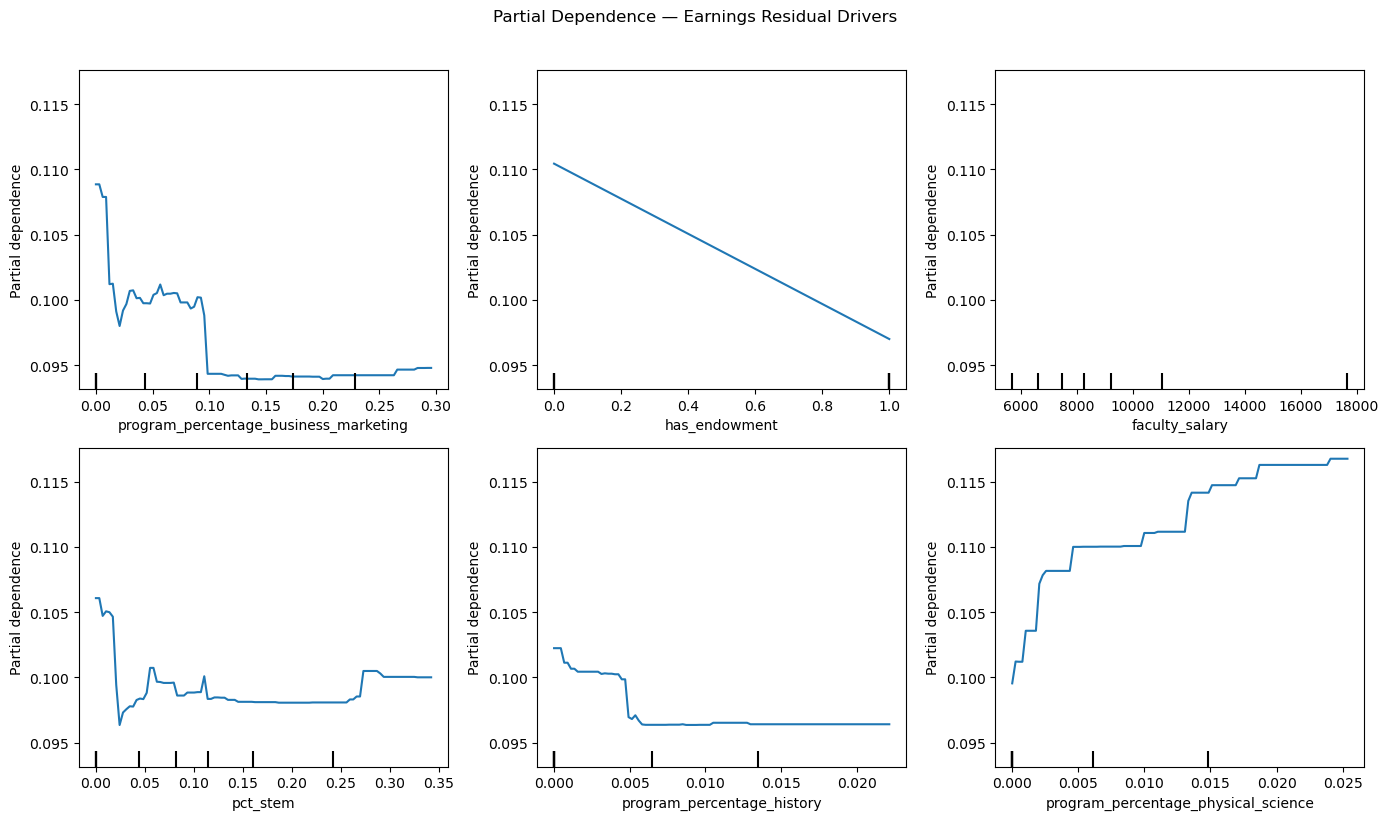

In [70]:
import math

n = len(top_features)  # 6
ncols = 3
nrows = math.ceil(n / ncols)  # 2

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
ax_flat = axes.flatten()  # gives you exactly 6 axes

PartialDependenceDisplay.from_estimator(
    pipe_stage2_final,
    X_train[stable_features],
    features=top_features,
    feature_names=stable_features,
    ax=ax_flat
)

plt.suptitle("Partial Dependence — Earnings Residual Drivers", y=1.02)
plt.tight_layout()
plt.savefig("pdp_plot.png", dpi=150, bbox_inches="tight")
plt.show()

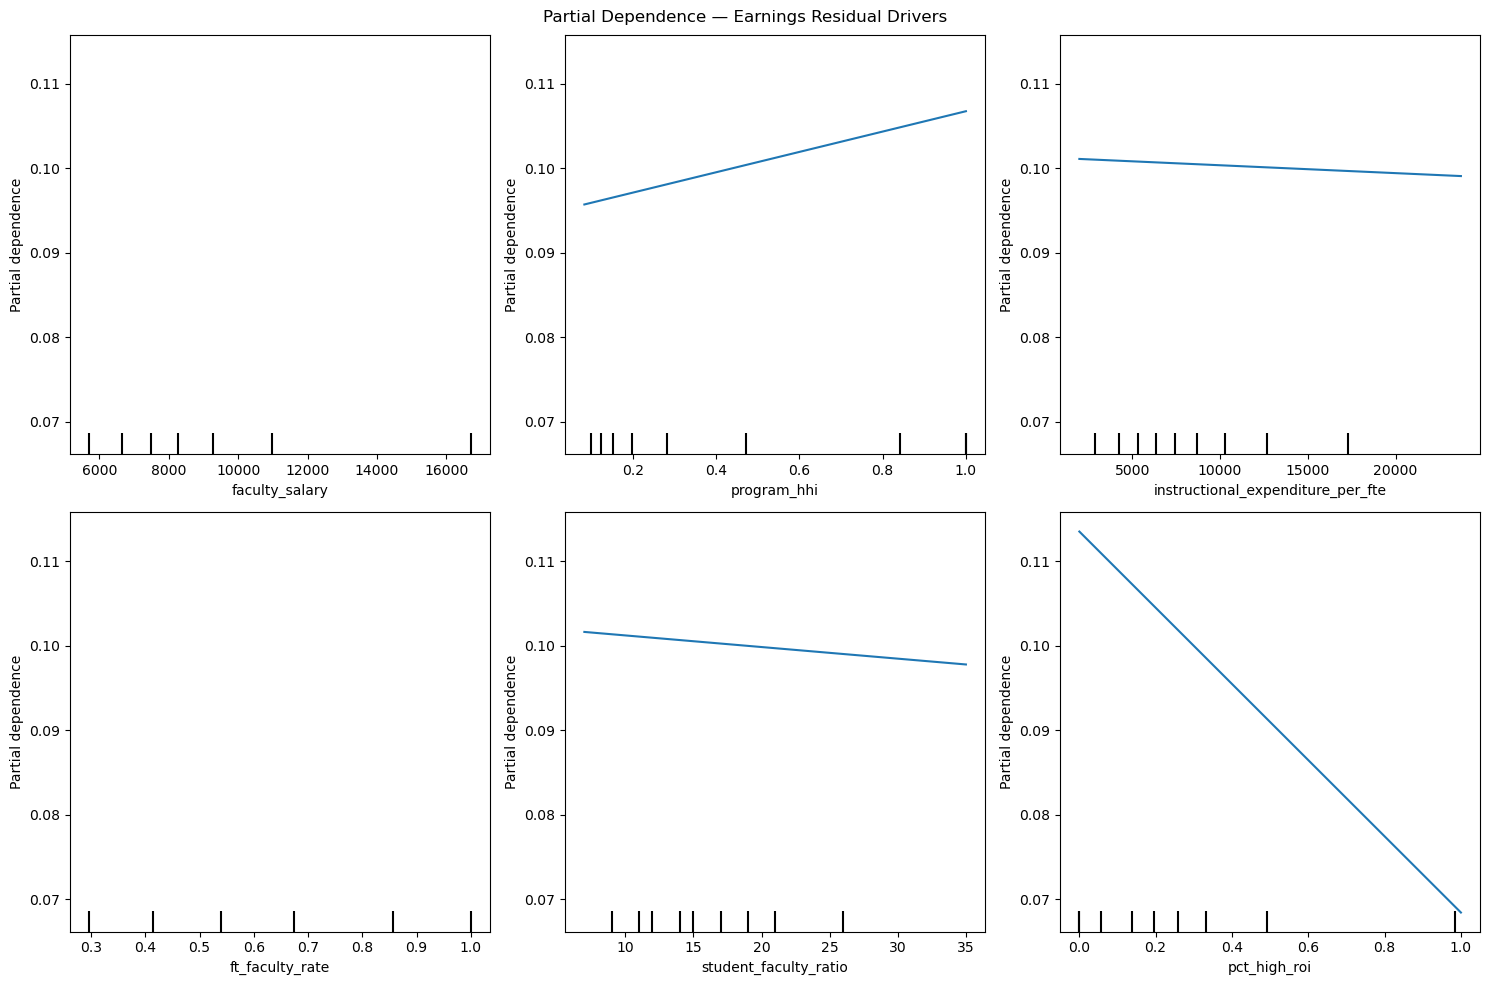

In [71]:
# fix by explicitly setting the grid resolution and percentile range
from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Partial Dependence — Earnings Residual Drivers")

features_to_plot = [
    "faculty_salary",
    "program_hhi", 
    "instructional_expenditure_per_fte",
    "ft_faculty_rate",
    "student_faculty_ratio",
    "pct_high_roi"
]

PartialDependenceDisplay.from_estimator(
    pipe_final,
    inst_model_df[stable_features],
    features=features_to_plot,
    ax=axes.flatten()[:len(features_to_plot)],
    percentiles=(0.05, 0.95),  # ← trim outliers that flatten the curve
    grid_resolution=50,         # ← explicit grid points
    n_jobs=-1
)

plt.tight_layout()
plt.show()

In [76]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.inspection import partial_dependence

def get_pd_data(model, X, feature, percentiles=(0.05, 0.95), grid_resolution=50):
    pd_result = partial_dependence(
        model,
        X,
        features=[feature],
        percentiles=percentiles,
        grid_resolution=grid_resolution,
        kind="average"
    )
    return pd_result["grid_values"][0], pd_result["average"][0]

# features to plot
features_to_plot = {
    "program_hhi":                          "Program Concentration (HHI)",
    "pct_high_roi":                         "% High ROI Programs",
    "program_percentage_philosophy_religious":"Program Percentage of Philosophy and Religion",
    "program_percentage_business_marketing":"% Business & Marketing",
    "student_faculty_ratio":                "Student Faculty Ratio",
    "instructional_expenditure_per_fte":    "Instructional Spend per FTE",
}

# build subplot grid
n = len(features_to_plot)
cols = 3
rows = (n + cols - 1) // cols

fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=list(features_to_plot.values()),
    vertical_spacing=0.15,
    horizontal_spacing=0.08
)

for i, (feat, label) in enumerate(features_to_plot.items()):
    row = i // cols + 1
    col = i % cols + 1

    x_vals, y_vals = get_pd_data(
        pipe_stage2_final,
        X[stable_features],
        feat
    )

    fig.add_trace(
        go.Scatter(
            x=x_vals,
            y=y_vals,
            mode="lines",
            line=dict(color="#2563EB", width=2.5),
            showlegend=False,
            hovertemplate=f"{label}<br>Value: %{{x:.3f}}<br>Residual: %{{y:.4f}}<extra></extra>"
        ),
        row=row, col=col
    )

    # add zero line for reference
    fig.add_hline(
        y=np.mean(y_vals),
        line_dash="dot",
        line_color="gray",
        line_width=1,
        row=row, col=col
    )

fig.update_layout(
    title=dict(
        text="Partial Dependence — Earnings Residual Drivers",
        font=dict(size=20),
        x=0.5
    ),
    height=600,
    width=1100,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Inter, Arial", size=12),
)

fig.update_xaxes(showgrid=True, gridcolor="#f0f0f0", zeroline=False)
fig.update_yaxes(showgrid=True, gridcolor="#f0f0f0", zeroline=False)

fig.show()

# save for presentation
# fig.write_html("partial_dependence.html")
# fig.write_image("partial_dependence.png", scale=2)  # needs kaleido: pip install kaleido

In [94]:
inst_model_df[targ].describe()

count    4327.000000
mean        0.021425
std         0.162703
min        -0.628108
25%        -0.063833
50%         0.009766
75%         0.094638
max         2.029032
Name: combined_pct_error, dtype: float64

In [98]:
# your data
pre_y_over = inst_model_df[targ]

# percentiles you care about
percentiles = [0.1, 0.2, 0.3, 0.7, 0.8, 0.9]
values = np.quantile(pre_y_over, percentiles)

# histogram
fig = px.histogram(pre_y_over, nbins=100, title="Target Distribution with Percentiles")

# add vertical lines
for p, v in zip(percentiles, values):
    fig.add_vline(
        x=v,
        line_dash="dash",
        annotation_text=f"{int(p*100)}%",
        annotation_position="top"
    )

fig.show()

In [92]:
np.log1p(inst_model_df[targ]).skew()

np.float64(-0.23754546356843945)

In [258]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score



# -------------------
# 1. Target (top vs bottom)
# -------------------
# y_raw = np.log1p(inst_model_df[targ])
# y_raw = y.clip(upper=y.quantile(0.95))
y_raw = inst_model_df[targ].copy()

low = y_raw.quantile(0.3)
high = y_raw.quantile(0.65)

mask = (y_raw <= low) | (y_raw >= high)

# -------------------
# 2. Use ALL columns except target
# -------------------
X_clf = inst_model_df.drop(columns=["unit_id", targ, "weight",'credential_level','code','avg_rank_stability','school_name'], errors="ignore").loc[mask].copy()
y_clf = (y_raw.loc[mask] >= high).astype(int)
w_clf = inst_model_df['weight'].loc[mask].copy()

# force everything numeric
X_clf = X_clf.apply(pd.to_numeric, errors="coerce")

# -------------------
# 3. Train/test split
# -------------------
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_clf,
    y_clf,
    w_clf,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

# -------------------
# 4. Preprocessing (CRITICAL)
# -------------------
num_cols = X_train.columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
])

In [215]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# -------------------
# 5. Model
# -------------------
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", LogisticRegression(max_iter=10000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []

for train_idx, val_idx in cv.split(X_clf, y_clf):
    X_tr = X_clf.iloc[train_idx]
    X_val = X_clf.iloc[val_idx]
    y_tr = y_clf.iloc[train_idx]
    y_val = y_clf.iloc[val_idx]
    w_tr = w_clf.iloc[train_idx]

    model = clone(clf)
    model.fit(X_tr, y_tr, logit__sample_weight=w_tr)

    val_proba = model.predict_proba(X_val)[:, 1]
    auc_scores.append(roc_auc_score(y_val, val_proba))

print(""" \
        LogisticRegression(max_iter=10000)
""")
print("AUC scores:", [round(s, 4) for s in auc_scores])
print("AUC mean:", round(np.mean(auc_scores), 4))
print("AUC std:", round(np.std(auc_scores), 4))

         LogisticRegression(max_iter=10000)

AUC scores: [0.6653, 0.6547, 0.6755, 0.699, 0.6506]
AUC mean: 0.669
AUC std: 0.0173


In [216]:
from sklearn.ensemble import HistGradientBoostingClassifier

clf_hgb = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", HistGradientBoostingClassifier(
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
    ))
])

auc_scores = []

for train_idx, val_idx in cv.split(X_clf, y_clf):
    X_tr = X_clf.iloc[train_idx]
    X_val = X_clf.iloc[val_idx]
    y_tr = y_clf.iloc[train_idx]
    y_val = y_clf.iloc[val_idx]
    w_tr = w_clf.iloc[train_idx]

    model = clone(clf_hgb)
    model.fit(X_tr, y_tr, logit__sample_weight=w_tr)

    val_proba = model.predict_proba(X_val)[:, 1]
    auc_scores.append(roc_auc_score(y_val, val_proba))

print(""" \
        HistGradientBoostingClassifier(
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
""")
print("AUC scores:", [round(s, 4) for s in auc_scores])
print("AUC mean:", round(np.mean(auc_scores), 4))
print("AUC std:", round(np.std(auc_scores), 4))

         HistGradientBoostingClassifier(
        max_depth=3,
        learning_rate=0.05,
        max_iter=200,
        random_state=42

AUC scores: [0.7049, 0.6922, 0.7357, 0.7274, 0.7097]
AUC mean: 0.714
AUC std: 0.0157


In [ ]:
from xgboost import XGBClassifier

xgb_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("logit", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"
    ))
])

auc_scores = []

for train_idx, val_idx in cv.split(X_clf, y_clf):
    X_tr = X_clf.iloc[train_idx]
    X_val = X_clf.iloc[val_idx]
    y_tr = y_clf.iloc[train_idx]
    y_val = y_clf.iloc[val_idx]
    w_tr = w_clf.iloc[train_idx]

    model = clone(xgb_clf)
    model.fit(X_tr, y_tr, logit__sample_weight=w_tr)

    val_proba = model.predict_proba(X_val)[:, 1]
    auc_scores.append(roc_auc_score(y_val, val_proba))

print(""" \
        XGBClassifier n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"
""")
print("AUC scores:", [round(s, 4) for s in auc_scores])
print("AUC mean:", round(np.mean(auc_scores), 4))
print("AUC std:", round(np.std(auc_scores), 4))

         XGBClassifier n_estimators=300,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"

AUC scores: [0.6987, 0.6856, 0.7355, 0.7328, 0.6922]
AUC mean: 0.709
AUC std: 0.021


In [218]:
# tune LogReg first — it's faster and might close the gap

C_values = [0.001, 0.01, 0.1, 1, 10, 100]

for C in C_values:
    clf = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(C=C, max_iter=10000))
    ])
    
    auc_scores = []
    for train_idx, val_idx in cv.split(X_clf, y_clf):
        X_tr, X_val = X_clf.iloc[train_idx], X_clf.iloc[val_idx]
        y_tr, y_val = y_clf.iloc[train_idx], y_clf.iloc[val_idx]
        w_tr = w_clf.iloc[train_idx]
        
        clone(clf).fit(X_tr, y_tr, logit__sample_weight=w_tr)
        model = clone(clf)
        model.fit(X_tr, y_tr, logit__sample_weight=w_tr)
        auc_scores.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
    
    print(f"C={C}: AUC={np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

C=0.001: AUC=0.6609 ± 0.0144
C=0.01: AUC=0.6693 ± 0.0185
C=0.1: AUC=0.6696 ± 0.0174
C=1: AUC=0.6690 ± 0.0173
C=10: AUC=0.6698 ± 0.0169
C=100: AUC=0.6704 ± 0.0162


In [219]:
import optuna

def objective(trial):
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    C = trial.suggest_float("C", 1e-3, 100.0, log=True)
    solver = "liblinear" if penalty == "l1" else trial.suggest_categorical(
        "solver_l2", ["lbfgs", "liblinear"]
    )

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("logit", LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            class_weight=class_weight,
            max_iter=10000,
            random_state=42
        ))
    ])

    # ← replace cross_val_score with manual loop
    auc_scores = []
    for train_idx, val_idx in cv.split(X_clf, y_clf):
        X_tr, X_val = X_clf.iloc[train_idx], X_clf.iloc[val_idx]
        y_tr, y_val = y_clf.iloc[train_idx], y_clf.iloc[val_idx]
        w_tr = w_clf.iloc[train_idx]

        model = clone(clf)
        model.fit(X_tr, y_tr, logit__sample_weight=w_tr)
        auc_scores.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))

    return float(np.mean(auc_scores))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best AUC:", study.best_value)
print("Params:", study.best_params)

[I 2026-04-11 17:08:01,336] A new study created in memory with name: no-name-8b31585a-5c74-40cf-b746-5db34528c570
[I 2026-04-11 17:08:01,557] Trial 0 finished with value: 0.5 and parameters: {'penalty': 'l1', 'class_weight': None, 'C': 0.00364458961813967}. Best is trial 0 with value: 0.5.
[I 2026-04-11 17:08:01,772] Trial 1 finished with value: 0.6650850175602651 and parameters: {'penalty': 'l2', 'class_weight': None, 'C': 0.0020770405183238665, 'solver_l2': 'liblinear'}. Best is trial 1 with value: 0.6650850175602651.
[I 2026-04-11 17:08:01,974] Trial 2 finished with value: 0.5864601828463215 and parameters: {'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.006421967019014283}. Best is trial 1 with value: 0.6650850175602651.
[I 2026-04-11 17:08:02,225] Trial 3 finished with value: 0.6689197030781189 and parameters: {'penalty': 'l2', 'class_weight': 'balanced', 'C': 0.00910994876866856, 'solver_l2': 'liblinear'}. Best is trial 3 with value: 0.6689197030781189.
[I 2026-04-11 17:08:0

Best AUC: 0.6703164964551103
Params: {'penalty': 'l2', 'class_weight': 'balanced', 'C': 93.69797186518542, 'solver_l2': 'lbfgs'}


In [220]:
def objective(trial):
    
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "max_iter": trial.suggest_int("max_iter", 100, 500),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 5.0),
        "random_state": 42
    }
    
    clf_hgb_o = Pipeline([
        ("preprocessor", preprocessor),   # 👈 your existing imputer+scaler
        ("hgbr", HistGradientBoostingClassifier(**params))
    ])
  
    
    val_scores = []
    train_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        w_tr = w_train.iloc[train_idx]

        m = clone(clf_hgb_o)
        m.fit(X_tr, y_tr, hgbr__sample_weight=w_tr)
        
        val_scores.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))
        train_scores.append(roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1]))

    mean_val = np.mean(val_scores)
    mean_train = np.mean(train_scores)
    gap = mean_train - mean_val

    # penalize overfitting — subtract gap from objective
    return mean_val - 0.5 * gap

hgbr_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
hgbr_study.optimize(objective, n_trials=100)

print("Best trial:")
print("CV AUC:", hgbr_study.best_value)
print("Params:", hgbr_study.best_params)

# -------------------
# 5. Fit best model on train
# -------------------
best_hgbr_params = hgbr_study.best_params.copy()
best_hgbr_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist"
})

# Fix 2: fit the full pipeline, not just XGBClassifier
best_hgbr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**best_hgbr_params))
])

best_hgbr.fit(X_train, y_train, model__sample_weight=w_train)  # ← pipeline fit

# then predictions through pipeline
hgbr_train_proba = best_hgbr.predict_proba(X_train)[:, 1]
hgbr_test_proba = best_hgbr.predict_proba(X_test)[:, 1]

[I 2026-04-11 17:10:42,318] A new study created in memory with name: no-name-20ac09d0-bcbf-4677-9f9c-9f1c7711d3a5
[I 2026-04-11 17:10:45,381] Trial 0 finished with value: 0.6053277063212976 and parameters: {'learning_rate': 0.030710573677773714, 'max_depth': 6, 'max_iter': 393, 'min_samples_leaf': 64, 'l2_regularization': 0.7800932022121826}. Best is trial 0 with value: 0.6053277063212976.
[I 2026-04-11 17:10:47,075] Trial 1 finished with value: 0.6464409838830528 and parameters: {'learning_rate': 0.015957084694148364, 'max_depth': 2, 'max_iter': 447, 'min_samples_leaf': 64, 'l2_regularization': 3.540362888980227}. Best is trial 1 with value: 0.6464409838830528.
[I 2026-04-11 17:10:51,150] Trial 2 finished with value: 0.6130479234854063 and parameters: {'learning_rate': 0.010636066512540286, 'max_depth': 6, 'max_iter': 433, 'min_samples_leaf': 29, 'l2_regularization': 0.9091248360355031}. Best is trial 1 with value: 0.6464409838830528.
[I 2026-04-11 17:10:52,768] Trial 3 finished with 

Best trial:
CV AUC: 0.6549650488035892
Params: {'learning_rate': 0.06604434330318629, 'max_depth': 2, 'max_iter': 119, 'min_samples_leaf': 93, 'l2_regularization': 3.5511860459550677}


c:\Users\sebas\miniconda3\envs\roi-fresh\lib\site-packages\xgboost\training.py:200: UserWarning: [17:12:33] WARNING: C:\Users\task_177467525606021\croot\xgboost-split_1774675332654\work\src\learner.cc:782: 
Parameters: { "l2_regularization", "max_iter", "min_samples_leaf" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [221]:
from sklearn.metrics import log_loss

hgbr_train_pred = (hgbr_train_proba >= 0.4876).astype(int)
hgbr_test_pred = (hgbr_test_proba >= 0.4876).astype(int)

# -------------------
# 7. Metrics
# -------------------
train_auc = roc_auc_score(y_train, hgbr_train_proba, sample_weight=w_train)
test_auc = roc_auc_score(y_test, hgbr_test_proba, sample_weight=w_test)

train_acc = accuracy_score(y_train, hgbr_train_pred)
test_acc = accuracy_score(y_test, hgbr_test_pred)

train_logloss = log_loss(y_train, hgbr_train_proba, sample_weight=w_train)
test_logloss = log_loss(y_test, hgbr_test_proba, sample_weight=w_test)

print("\nHGBClassifier")
print("Train AUC:", round(train_auc, 4))
print("Test AUC:", round(test_auc, 4))
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Train LogLoss:", round(train_logloss, 4))
print("Test LogLoss:", round(test_logloss, 4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, hgbr_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, hgbr_test_pred, digits=4))


HGBClassifier
Train AUC: 0.7857
Test AUC: 0.7221
Train Accuracy: 0.7227
Test Accuracy: 0.66
Train LogLoss: 0.5858
Test LogLoss: 0.6179

Confusion Matrix (Test):
[[207 182]
 [105 350]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.6635    0.5321    0.5906       389
           1     0.6579    0.7692    0.7092       455

    accuracy                         0.6600       844
   macro avg     0.6607    0.6507    0.6499       844
weighted avg     0.6605    0.6600    0.6545       844



In [222]:
# add weighted F1 and AP since you're weighting everything else
from sklearn.metrics import average_precision_score, f1_score

hgbc_train_ap = average_precision_score(y_train, hgbr_train_proba, sample_weight=w_train)
hgbc_test_ap = average_precision_score(y_test, hgbr_test_proba, sample_weight=w_test)
hgbc_train_f1 = f1_score(y_train, hgbr_train_pred, sample_weight=w_train)
hgbc_test_f1 = f1_score(y_test, hgbr_test_pred, sample_weight=w_test)

print("Train AP:", round(hgbc_train_ap, 4))
print("Test AP:", round(hgbc_test_ap, 4))
print("Train F1:", round(hgbc_train_f1, 4))
print("Test F1:", round(hgbc_test_f1, 4))

Train AP: 0.7862
Test AP: 0.7408
Train F1: 0.7666
Test F1: 0.7094


In [223]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, f1_score, precision_score, recall_score

# compute metrics across thresholds
thresholds = np.linspace(0.01, 0.99, 200)

metrics = {
    "f1": [], "precision": [], "recall": [], "accuracy": []
}

for t in thresholds:
    hgbc_preds = (hgbr_train_proba >= t).astype(int)
    metrics["f1"].append(f1_score(y_train, hgbc_preds, zero_division=0))
    metrics["precision"].append(precision_score(y_train, hgbc_preds, zero_division=0))
    metrics["recall"].append(recall_score(y_train, hgbc_preds, zero_division=0))
    metrics["accuracy"].append(accuracy_score(y_train, hgbc_preds))

# find best F1 threshold
best_idx = np.argmax(metrics["f1"])
hgbc_best_thresh = thresholds[best_idx]

fig = go.Figure()

fig.add_trace(go.Scatter(x=thresholds, y=metrics["f1"],
    name="F1", line=dict(color="#636EFA", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["precision"],
    name="Precision", line=dict(color="#EF553B", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["recall"],
    name="Recall", line=dict(color="#00CC96", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["accuracy"],
    name="Accuracy", line=dict(color="#FFA15A", width=2)))

# best threshold line
fig.add_vline(
    x=hgbc_best_thresh,
    line_dash="dash",
    line_color="white",
    annotation_text=f"Best F1 threshold: {hgbc_best_thresh:.3f}",
    annotation_position="top right"
)

fig.update_layout(
    title="Threshold vs Classification Metrics (Train)",
    xaxis_title="Threshold",
    yaxis_title="Score",
    legend=dict(orientation="h", y=-0.15),
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()
print(f"\nBest F1 threshold: {hgbc_best_thresh:.4f}")
print(f"At this threshold — F1: {metrics['f1'][best_idx]:.4f} | "
      f"Precision: {metrics['precision'][best_idx]:.4f} | "
      f"Recall: {metrics['recall'][best_idx]:.4f}")

# apply to test
hgbc_test_pred_tuned = (hgbr_test_proba >= hgbc_best_thresh).astype(int)
print(f"\nTest set with tuned threshold ({hgbc_best_thresh:.3f}):")
print(confusion_matrix(y_test, hgbc_test_pred_tuned))
print(classification_report(y_test, hgbc_test_pred_tuned, digits=4))


Best F1 threshold: 0.4187
At this threshold — F1: 0.7684 | Precision: 0.6473 | Recall: 0.9453

Test set with tuned threshold (0.419):
[[131 258]
 [ 46 409]]
              precision    recall  f1-score   support

           0     0.7401    0.3368    0.4629       389
           1     0.6132    0.8989    0.7291       455

    accuracy                         0.6398       844
   macro avg     0.6767    0.6178    0.5960       844
weighted avg     0.6717    0.6398    0.6064       844



In [224]:
from sklearn.metrics import roc_curve, f1_score, precision_score, recall_score

# find optimal threshold on training set
fpr, tpr, thresholds = roc_curve(y_train, hgbr_train_proba)

# maximize F1 on train
best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    preds = (hgbr_train_proba >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Optimal threshold: {best_thresh:.4f}")

# apply to test
test_pred_tuned = (hgbr_test_proba >= best_thresh).astype(int)

print("\nTuned threshold metrics:")
print(confusion_matrix(y_test, test_pred_tuned))
print(classification_report(y_test, test_pred_tuned, digits=4))

Optimal threshold: 0.4187

Tuned threshold metrics:
[[131 258]
 [ 46 409]]
              precision    recall  f1-score   support

           0     0.7401    0.3368    0.4629       389
           1     0.6132    0.8989    0.7291       455

    accuracy                         0.6398       844
   macro avg     0.6767    0.6178    0.5960       844
weighted avg     0.6717    0.6398    0.6064       844



In [225]:
kf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "max_iter": trial.suggest_int("max_iter", 100, 500),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 5.0),
        "random_state": 42
    }

    hgbr_o = Pipeline([
        ("preprocessor", preprocessor),
        ("hgbr", HistGradientBoostingRegressor(**params))
    ])

    r2_scores = []
    for train_idx, val_idx in kf_cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        w_tr = w.iloc[train_idx]

        model = clone(hgbr_o)
        model.fit(X_tr, y_tr, hgbr__sample_weight=w_tr)

        preds = model.predict(X_val)
        r2_scores.append(r2_score(y_val, preds))

    return float(np.mean(r2_scores))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print("R2:", study.best_value)
print("Params:", study.best_params)

[I 2026-04-11 17:12:37,058] A new study created in memory with name: no-name-7898d268-5918-4f91-85a4-55e05d8f165c
[I 2026-04-11 17:12:39,411] Trial 0 finished with value: 0.15292464655234042 and parameters: {'learning_rate': 0.06326194959782022, 'max_depth': 4, 'max_iter': 332, 'min_samples_leaf': 66, 'l2_regularization': 2.3606984475264636}. Best is trial 0 with value: 0.15292464655234042.
[I 2026-04-11 17:12:42,541] Trial 1 finished with value: 0.1405079318358562 and parameters: {'learning_rate': 0.11690268379033307, 'max_depth': 6, 'max_iter': 332, 'min_samples_leaf': 81, 'l2_regularization': 4.965352258624244}. Best is trial 0 with value: 0.15292464655234042.
[I 2026-04-11 17:12:45,908] Trial 2 finished with value: 0.1502868000181356 and parameters: {'learning_rate': 0.05161050522882049, 'max_depth': 6, 'max_iter': 357, 'min_samples_leaf': 94, 'l2_regularization': 3.6070921083068113}. Best is trial 0 with value: 0.15292464655234042.
[I 2026-04-11 17:12:48,015] Trial 3 finished with

Best trial:
R2: 0.1704186810446696
Params: {'learning_rate': 0.029236485116861135, 'max_depth': 6, 'max_iter': 431, 'min_samples_leaf': 14, 'l2_regularization': 2.5246754879629383}


In [226]:
# Fix 1: Optuna objective — replace cross_val_score with manual loop
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 3.0),

        # fixed
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist"
    }
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(**params))
    ])

    val_scores = []
    train_scores = []
    
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        w_tr = w_train.iloc[train_idx]

        m = clone(model)
        m.fit(X_tr, y_tr, model__sample_weight=w_tr)
        
        val_scores.append(roc_auc_score(y_val, m.predict_proba(X_val)[:, 1]))
        train_scores.append(roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1]))

    mean_val = np.mean(val_scores)
    mean_train = np.mean(train_scores)
    gap = mean_train - mean_val

    # penalize overfitting — subtract gap from objective
    return mean_val - 0.5 * gap

xgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
xgb_study.optimize(objective, n_trials=100)

print("Best trial:")
print("CV AUC:", xgb_study.best_value)
print("Params:", xgb_study.best_params)

# -------------------
# 5. Fit best model on train
# -------------------
best_params = xgb_study.best_params.copy()
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist"
})

# Fix 2: fit the full pipeline, not just XGBClassifier
best_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(**best_params))
])

best_xgb.fit(X_train, y_train, model__sample_weight=w_train)  # ← pipeline fit


[I 2026-04-11 17:15:21,088] A new study created in memory with name: no-name-fd28037f-6a41-4521-a503-d5ab9df0be64
[I 2026-04-11 17:15:22,817] Trial 0 finished with value: 0.6199930917493128 and parameters: {'n_estimators': 287, 'max_depth': 6, 'learning_rate': 0.044803926826840625, 'min_child_weight': 9, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 2.1423021757741068, 'gamma': 3.005575058716044, 'scale_pos_weight': 2.2701814444901136}. Best is trial 0 with value: 0.6199930917493128.
[I 2026-04-11 17:15:23,861] Trial 1 finished with value: 0.6140275882085485 and parameters: {'n_estimators': 110, 'max_depth': 6, 'learning_rate': 0.060534484680010825, 'min_child_weight': 4, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 0.0033205591037519565, 'reg_lambda': 0.042051564509138675, 'gamma': 2.1597250932105787, 'scale_pos_weight': 1.2280728504951048}. Best is trial 0 with value:

Best trial:
CV AUC: 0.6615039292473566
Params: {'n_estimators': 586, 'max_depth': 2, 'learning_rate': 0.009826547602402601, 'min_child_weight': 4, 'subsample': 0.6852850732357625, 'colsample_bytree': 0.8475396952383423, 'reg_alpha': 0.000840034740463124, 'reg_lambda': 0.0030780194501046645, 'gamma': 4.533891065232115, 'scale_pos_weight': 2.384706800480133}


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [227]:
# then predictions through pipeline
train_proba = best_xgb.predict_proba(X_train)[:, 1]
test_proba = best_xgb.predict_proba(X_test)[:, 1]

train_pred = (train_proba >= 0.6845).astype(int)
test_pred = (test_proba >= 0.6945).astype(int)

# -------------------
# 7. Metrics
# -------------------
train_auc = roc_auc_score(y_train, train_proba, sample_weight=w_train)
test_auc = roc_auc_score(y_test, test_proba, sample_weight=w_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_logloss = log_loss(y_train, train_proba, sample_weight=w_train)
test_logloss = log_loss(y_test, test_proba, sample_weight=w_test)

print("\nXGBClassifier")
print("Train AUC:", round(train_auc, 4))
print("Test AUC:", round(test_auc, 4))
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Train LogLoss:", round(train_logloss, 4))
print("Test LogLoss:", round(test_logloss, 4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, digits=4))


XGBClassifier
Train AUC: 0.7838
Test AUC: 0.7262
Train Accuracy: 0.7161
Test Accuracy: 0.6659
Train LogLoss: 0.6502
Test LogLoss: 0.6812

Confusion Matrix (Test):
[[220 169]
 [113 342]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.6607    0.5656    0.6094       389
           1     0.6693    0.7516    0.7081       455

    accuracy                         0.6659       844
   macro avg     0.6650    0.6586    0.6587       844
weighted avg     0.6653    0.6659    0.6626       844



In [228]:
# add weighted F1 and AP since you're weighting everything else
from sklearn.metrics import average_precision_score, f1_score, roc_curve

train_ap = average_precision_score(y_train, train_proba, sample_weight=w_train)
test_ap = average_precision_score(y_test, test_proba, sample_weight=w_test)
train_f1 = f1_score(y_train, train_pred, sample_weight=w_train)
test_f1 = f1_score(y_test, test_pred, sample_weight=w_test)

print("Train AP:", round(train_ap, 4))
print("Test AP:", round(test_ap, 4))
print("Train F1:", round(train_f1, 4))
print("Test F1:", round(test_f1, 4))

Train AP: 0.7814
Test AP: 0.7528
Train F1: 0.7622
Test F1: 0.7084


In [229]:
# find optimal threshold on training set
fpr, tpr, thresholds = roc_curve(y_train, train_proba)

# maximize F1 on train
best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    preds = (train_proba >= t).astype(int)
    f1 = f1_score(y_train, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Optimal threshold: {best_thresh:.4f}")

# apply to test
test_pred_tuned = (test_proba >= best_thresh).astype(int)

print("\nTuned threshold metrics:")
print(confusion_matrix(y_test, test_pred_tuned))
print(classification_report(y_test, test_pred_tuned, digits=4))

Optimal threshold: 0.6165

Tuned threshold metrics:
[[139 250]
 [ 43 412]]
              precision    recall  f1-score   support

           0     0.7637    0.3573    0.4869       389
           1     0.6224    0.9055    0.7377       455

    accuracy                         0.6528       844
   macro avg     0.6930    0.6314    0.6123       844
weighted avg     0.6875    0.6528    0.6221       844



In [230]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, f1_score, precision_score, recall_score

# compute metrics across thresholds
thresholds = np.linspace(0.01, 0.99, 200)

metrics = {
    "f1": [], "precision": [], "recall": [], "accuracy": []
}

for t in thresholds:
    preds = (train_proba >= t).astype(int)
    metrics["f1"].append(f1_score(y_train, preds, zero_division=0))
    metrics["precision"].append(precision_score(y_train, preds, zero_division=0))
    metrics["recall"].append(recall_score(y_train, preds, zero_division=0))
    metrics["accuracy"].append(accuracy_score(y_train, preds))

# find best F1 threshold
best_idx = np.argmax(metrics["f1"])
best_thresh = thresholds[best_idx]

fig = go.Figure()

fig.add_trace(go.Scatter(x=thresholds, y=metrics["f1"],
    name="F1", line=dict(color="#636EFA", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["precision"],
    name="Precision", line=dict(color="#EF553B", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["recall"],
    name="Recall", line=dict(color="#00CC96", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["accuracy"],
    name="Accuracy", line=dict(color="#FFA15A", width=2)))

# best threshold line
fig.add_vline(
    x=best_thresh,
    line_dash="dash",
    line_color="white",
    annotation_text=f"Best F1 threshold: {best_thresh:.3f}",
    annotation_position="top right"
)

fig.update_layout(
    title="Threshold vs Classification Metrics (Train)",
    xaxis_title="Threshold",
    yaxis_title="Score",
    legend=dict(orientation="h", y=-0.15),
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()
print(f"\nBest F1 threshold: {best_thresh:.4f}")
print(f"At this threshold — F1: {metrics['f1'][best_idx]:.4f} | "
      f"Precision: {metrics['precision'][best_idx]:.4f} | "
      f"Recall: {metrics['recall'][best_idx]:.4f}")

# apply to test
test_pred_tuned = (test_proba >= best_thresh).astype(int)
print(f"\nTest set with tuned threshold ({best_thresh:.3f}):")
print(confusion_matrix(y_test, test_pred_tuned))
print(classification_report(y_test, test_pred_tuned, digits=4))


Best F1 threshold: 0.6108
At this threshold — F1: 0.7752 | Precision: 0.6556 | Recall: 0.9481

Test set with tuned threshold (0.611):
[[135 254]
 [ 41 414]]
              precision    recall  f1-score   support

           0     0.7670    0.3470    0.4779       389
           1     0.6198    0.9099    0.7373       455

    accuracy                         0.6505       844
   macro avg     0.6934    0.6285    0.6076       844
weighted avg     0.6876    0.6505    0.6177       844



In [40]:
# average the probabilities from both models
ensemble_proba = (test_proba + xgb_preds) / 2
ensemble_auc = roc_auc_score(y_test, ensemble_proba, sample_weight=w_test)
print("Ensemble AUC:", round(ensemble_auc, 4))

NameError: name 'test_proba' is not defined

In [236]:
# weight better model more
w_xgb, w_hgb = 0.6, 0.4
ensemble_train_proba = w_xgb * train_proba + w_hgb * hgbr_train_proba
ensemble_test_proba = w_xgb * test_proba + w_hgb * hgbr_test_proba

In [240]:
# then predictions through pipeline
ensemble_train_proba = best_xgb.predict_proba(X_train)[:, 1]
ensemble_test_proba = best_xgb.predict_proba(X_test)[:, 1]

train_pred = (ensemble_train_proba >= 0.537).astype(int)
test_pred = (ensemble_test_proba >= 0.537).astype(int)

# -------------------
# 7. Metrics
# -------------------
train_auc = roc_auc_score(y_train, ensemble_train_proba, sample_weight=w_train)
test_auc = roc_auc_score(y_test, ensemble_test_proba, sample_weight=w_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_logloss = log_loss(y_train, ensemble_train_proba, sample_weight=w_train)
test_logloss = log_loss(y_test, ensemble_test_proba, sample_weight=w_test)

print("\nEnsemble")
print("Train AUC:", round(train_auc, 4))
print("Test AUC:", round(test_auc, 4))
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))
print("Train LogLoss:", round(train_logloss, 4))
print("Test LogLoss:", round(test_logloss, 4))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, digits=4))


Ensemble
Train AUC: 0.7838
Test AUC: 0.7262
Train Accuracy: 0.6389
Test Accuracy: 0.6031
Train LogLoss: 0.6502
Test LogLoss: 0.6812

Confusion Matrix (Test):
[[ 75 314]
 [ 21 434]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.7812    0.1928    0.3093       389
           1     0.5802    0.9538    0.7215       455

    accuracy                         0.6031       844
   macro avg     0.6807    0.5733    0.5154       844
weighted avg     0.6729    0.6031    0.5315       844



In [238]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, f1_score, precision_score, recall_score

# compute metrics across thresholds
thresholds = np.linspace(0.01, 0.99, 200)

metrics = {
    "f1": [], "precision": [], "recall": [], "accuracy": []
}

for t in thresholds:
    preds = (ensemble_train_proba >= t).astype(int)
    metrics["f1"].append(f1_score(y_train, preds, zero_division=0))
    metrics["precision"].append(precision_score(y_train, preds, zero_division=0))
    metrics["recall"].append(recall_score(y_train, preds, zero_division=0))
    metrics["accuracy"].append(accuracy_score(y_train, preds))

# find best F1 threshold
best_idx = np.argmax(metrics["f1"])
best_thresh = thresholds[best_idx]

fig = go.Figure()

fig.add_trace(go.Scatter(x=thresholds, y=metrics["f1"],
    name="F1", line=dict(color="#636EFA", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["precision"],
    name="Precision", line=dict(color="#EF553B", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["recall"],
    name="Recall", line=dict(color="#00CC96", width=2)))
fig.add_trace(go.Scatter(x=thresholds, y=metrics["accuracy"],
    name="Accuracy", line=dict(color="#FFA15A", width=2)))

# best threshold line
fig.add_vline(
    x=best_thresh,
    line_dash="dash",
    line_color="white",
    annotation_text=f"Best F1 threshold: {best_thresh:.3f}",
    annotation_position="top right"
)

fig.update_layout(
    title="Threshold vs Classification Metrics (Train)",
    xaxis_title="Threshold",
    yaxis_title="Score",
    legend=dict(orientation="h", y=-0.15),
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()
print(f"\nBest F1 threshold: {best_thresh:.4f}")
print(f"At this threshold — F1: {metrics['f1'][best_idx]:.4f} | "
      f"Precision: {metrics['precision'][best_idx]:.4f} | "
      f"Recall: {metrics['recall'][best_idx]:.4f}")

# apply to test
test_pred_tuned = (ensemble_test_proba >= best_thresh).astype(int)
print('Ensemble')
print(f"\nTest set with tuned threshold ({best_thresh:.3f}):")
print(confusion_matrix(y_test, test_pred_tuned))
print(classification_report(y_test, test_pred_tuned, digits=4))


Best F1 threshold: 0.5369
At this threshold — F1: 0.7742 | Precision: 0.6551 | Recall: 0.9462
Ensemble

Test set with tuned threshold (0.537):
[[133 256]
 [ 46 409]]
              precision    recall  f1-score   support

           0     0.7430    0.3419    0.4683       389
           1     0.6150    0.8989    0.7304       455

    accuracy                         0.6422       844
   macro avg     0.6790    0.6204    0.5993       844
weighted avg     0.6740    0.6422    0.6096       844

